# SLSN Detection Metrics for Rubin/LSST
## Rubin Observatory Metrics Analysis Framework (MAF) — Superluminous Supernovae

This notebook evaluates the Rubin Observatory Legacy Survey of Space and Time (LSST)
baseline cadence's ability to detect, characterize, and trigger spectroscopic follow-up
of Superluminous Supernovae (SLSNe) across cosmic time.

### Overview of the Pipeline
The pipeline consists of five stages:
1. **Templates** — Gaussian Process light curve templates built from observed SLSN photometry (Sebastian Gomez's database, 261 events)
2. **Magnitude grid** — Pre-computed apparent magnitudes across redshift and phase for fast metric evaluation
3. **Population** — A simulated volumetric population of SLSNe sampled from a metallicity-dependent rate model
4. **Metrics** — Three MAF metrics (detection, characterization, spectroscopic trigger) evaluated against the OpSim cadence database
5. **Diagnostics** — Efficiency maps, light curve mosaics, and population-level summary plots

### Key Parameters

| Parameter | Value | Justification |
|---|---|---|
| `z_min / z_max` | 0.1 – 2.0 | Rubin's effective SLSN detection horizon; below 0.1 volume is negligible |
| `rate_model` | `evolving` | Metallicity-dependent R(z); see Rate Model section below |
| `R_ref` | 1×10⁻⁷ Mpc⁻³ yr⁻¹ | Quimby+2013 at z=0.17, the best-constrained low-z measurement |
| `OH_max` | 9.0 | Calibrated metallicity threshold; see Rate Model section |
| `gal_lat_cut` | 15° | Removes high-extinction Galactic plane events; standard for extragalactic surveys |
| `seed` | 42 | Fixed for reproducibility |

### Toggle Flags
- `GENERATE_NEW_TEMPLATES` — Set True only when adding new SLSN events to the catalog
- `GENERATE_NEW_POPULATION` — Set True when changing rate model, z range, or OH_max
- `FORCE_REBUILD_MAG_GRID` — Set True when changing templates or z range
- `MAKE_DEBUG_PLOTS` — Shows population diagnostics; safe to leave True

In [1]:
# ============================================================================
# CELL 1: Machine configuration — set your machine flag here
# ============================================================================
import sys, os
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path
import astropy.units as u
from astropy.cosmology import Planck18 as cosmo

import sys, os
sys.path.insert(0, "/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric")


#--- One-time: point rubin_sim at its data ---
# Only needed if RUBIN_SIM_DATA_DIR isn't already in your shell environment
from slsn_metrics.paths import set_rubin_sim_data_dir
set_rubin_sim_data_dir("/users/1/andra104/rubin_sim_data")  # adjust if different

# --- Verify everything resolves correctly ---
from slsn_metrics.paths import print_paths
print_paths(cadence_name='baseline_v5.1.0_10yrs', science_case='SLSNe')

# --- All other imports ---
from slsn_metrics.model import LC, CatalogInputs, atomic_save_pickle
from slsn_metrics.metrics import SLSN_Detect_Metric, SLSN_CharacterizeMetric, SLSN_SpecTriggerMetric
from slsn_metrics.population import generate_SLSN_PopSlicer
from slsn_metrics.runners import run_slsn_detect, run_slsn_multi_metrics, build_filenames
from slsn_metrics.diagnostics import plot_metrics_mosaic_grid, plot_population_diagnostics

[paths] RUBIN_SIM_DATA_DIR = /users/1/andra104/rubin_sim_data

📁  SLSN METRICS — PATH STRUCTURE

📂 Repo root      : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric
                    ✓ exists

📂 Cadences dir   : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/cadences
                    ✓ exists

📂 Output dir     : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe
                    ✓ exists

📂 Shared outputs : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/shared
                    ✓ exists

📂 Data dir       : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/per_event_files
                    ✓ exists

🌌 RUBIN_SIM_DATA : /users/1/andra104/rubin_sim_data
                    ✓ exists

📂 Cadence databases:
   ✓ exists  baseline_v5.1.0_10yrs.db
              /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/cadences/baseline_v5.1.0_10yrs

In [2]:
# ============================================================================
# CELL 2: Configuration — edit this cell to change runs
# ============================================================================

# --- Toggles ---
GENERATE_NEW_TEMPLATES = False   # True = rebuild GP templates from photometry
GENERATE_NEW_MAG_GRID  = False   # True = recompute mag grid (~5-10 min on MSI)
GENERATE_NEW_POPULATION = False  # True = resample population from rate model
MAKE_DEBUG_PLOTS        = True   # Toggle population diagnostic plots

# --- Template parameters ---
# Only matter when GENERATE_NEW_TEMPLATES = True
# If loading existing templates, these are informational only
tpad_pre_days  = 5.0
tpad_post_days = 160.0
n_time         = 220

# --- Magnitude grid parameters ---
# Only matter when GENERATE_NEW_MAG_GRID = True
# IMPORTANT: z_grid here must cover at least z_min to z_max below
z_grid_mag    = np.linspace(0.02, 2.0, 50)
phase_grid_mag = np.geomspace(0.1, 160, 200)
filters        = 'ugrizy'

# --- Rate model ---
rate_model = 'evolving'   # 'evolving' or 'constant'

# Evolving rate parameters (used when rate_model='evolving')
R_ref  = 1e-7   # Quimby+13 reference rate [Mpc^-3 yr^-1]
z_ref  = 0.17   # Quimby+13 reference redshift
OH_max = 9.0    # Schulze+21 metallicity threshold

# Constant rate parameters (used when rate_model='constant')
rate_density = 1e-7   # [Mpc^-3 yr^-1]

# --- Population parameters ---
z_min      = 0.1
z_max      = 2.0       # Full range — use MSI for this
t_start    = 1         # Survey start [days]
t_end      = 3652      # Survey end [days] — 10 years
gal_lat_cut = 15.0     # Galactic latitude cut [deg]
seed       = 42

# --- Cadence / metric parameters ---
cadences       = ['baseline_v5.1.0_10yrs']
mjd0           = 60980.5
ignore_triples = True
store_obs_mode = "full"   # "none", "meta", "diag", or "full"
                          # Use "full" for mosaic plots, "none" for large runs

# --- Testname tags (appended to filenames) ---
testname             = None   # Tags templates + population filenames
testname_metric_only = None   # Tags observation record filename only
                              # Use when only changing detection criteria

# --- Other ---
clean_temp   = True    # Remove Metric_temp_* folders after run
make_plots   = True    # Generate HEALPix efficiency maps

print("✓ Configuration loaded")
print(f"  rate_model : {rate_model}")
print(f"  z range    : {z_min} → {z_max}")
print(f"  cadences   : {cadences}")
print(f"  toggles    : templates={GENERATE_NEW_TEMPLATES}, mag_grid={GENERATE_NEW_MAG_GRID}, pop={GENERATE_NEW_POPULATION}")

✓ Configuration loaded
  rate_model : evolving
  z range    : 0.1 → 2.0
  cadences   : ['baseline_v5.1.0_10yrs']
  toggles    : templates=False, mag_grid=False, pop=False


In [3]:
# ============================================================================
# CELL 3: Resolve filenames from configuration
# ============================================================================
from slsn_metrics.paths import get_shared_output_dir, get_output_dir
from slsn_metrics.runners import build_filenames

shared_dir = get_shared_output_dir("SLSNe")
output_dir = get_output_dir("SLSNe")

# Build standardized filenames from parameters
# These encode the key parameters so different runs don't overwrite each other
templates_file, pop_file, df_file, storage_dir, summary_filename = build_filenames(
    rate_density  = R_ref if rate_model == 'evolving' else rate_density,
    z_min         = z_min,
    z_max         = z_max,
    d_min         = None,
    d_max         = None,
    science_case  = "SLSNe",
    testname      = testname,
    testname_metric_only = testname_metric_only,
    ignore_triples       = ignore_triples,
    use_extinction       = True,
    use_kcorrect         = False,
)

mag_grid_file = templates_file.replace("_templates.pkl", "_mag_grid.pkl")

print(f"✓ File paths resolved:")
print(f"  templates  : {templates_file}")
print(f"  mag grid   : {mag_grid_file}")
print(f"  population : {pop_file}")
print(f"  obs record : {df_file}")
print(f"  summary    : {summary_filename}")
print(f"  storage    : {storage_dir}")

SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None
✓ File paths resolved:
  templates  : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None_templates.pkl
  mag grid   : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None_mag_grid.pkl
  population : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None_population.pkl
  obs record : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None_None_it_True_obs_record
  summary    : /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None_None_it_True_multi_summary.cs

## Stage 1: Light Curve Templates

Templates are 2D Gaussian Process fits to observed SLSN photometry from
Sebastian Gomez's database. Each template captures the multi-band spectral
energy distribution (SED) evolution of one real SLSN event across time and
wavelength simultaneously.

### Why Gaussian Processes?
GP regression is used because SLSN light curves are:
- Irregularly sampled across time and wavelength
- Observed in heterogeneous filter systems (ZTF, PTF, PS1, SDSS, etc.)
- Sometimes sparsely sampled at early or late phases

The GP fits a smooth 2D surface over (phase [days], frequency [Hz]) space,
enabling interpolation to any Rubin filter at any observed epoch without
assuming a parametric light curve shape.

### GP Kernel Choice: Matérn-3/2
The kernel used is a 2D Matérn-3/2:

    k(x, x') = amplitude² × Matérn32([time_scale², freq_scale²])

**Why Matérn-3/2 specifically?**
- Produces once-differentiable functions — appropriate for light curves
  which have smooth but not infinitely smooth evolution
- Squared-exponential (RBF) would over-smooth sharp features like the
  rise and peak; Matérn-1/2 would be too rough
- Standard choice in astronomical light curve interpolation literature

**Kernel parameters:**
- Time scale: 20 days — characteristic SLSN variability timescale
- Frequency scale: 1×10¹⁴ Hz — frozen to stabilize fits when color
  coverage is sparse (prevents the GP from fitting noise across wavelength)
- Frequency metric frozen: prevents over-fitting when only 1-2 filters
  are observed, which would otherwise produce unphysical color evolution

### How the GP Uses Band Information: Frequency-Space Fitting
A critical design decision is that the GP is fit entirely in physical
frequency space (Hz), not in named-band space. Here is the exact sequence:

1. Each photometry CSV contains a `Cenwave` column — the central wavelength
   in Ångströms for every observation. This is converted to frequency (Hz)
   and used as the second GP input dimension alongside time.
2. The GP is trained on (time [days], frequency [Hz]) → flux [Jy] with no
   reference to band names at all. The band label `'B'`, `'V'`, `'R'` is
   irrelevant to the fit itself.
3. After fitting, the GP surface is evaluated at the **median central
   wavelength of each observed band** for that specific event. The resulting
   absolute magnitude curve is stored back under the original catalog band
   label — so `templates.data[0]['B']` holds the GP prediction at the median
   Cenwave of B-band observations for event 0, in absolute magnitudes.

This means the templates preserve catalog band labels (`'B'`, `'V'`, `'R'`)
not as filter definitions but as convenient keys pointing to the physical
wavelength region where observations existed. The label is a shorthand for
the Cenwave it represents.

### What the Templates Do NOT Contain
Templates store absolute magnitudes at the observed catalog wavelengths only.
They do not contain LSST filter magnitudes directly. The translation to LSST
filters happens in Stage 2 (magnitude grid), described in the next cell.

### Why Direct Magnitude Mapping Instead of SED Synthesis?
Full SED synthesis (integrating F_ν over the LSST filter bandpass) requires
dense wavelength coverage. Most SLSN catalog events have only 2–3 filters,
making SED synthesis unreliable. Direct magnitude mapping with empirical
color offsets (derived from typical hot SLSN SEDs, T~10,000–15,000 K) is
more robust for sparsely sampled data. The color offsets are small
(≤0.15 mag) and well within the systematic uncertainty of the rate model.

### Template Statistics
- Input catalog: 265 SLSN events (Sebastian Gomez database)
- Valid templates (wavelength coverage > 2000 Å): ~261
- Templates used in population (sufficient ugrizy coverage): ~165

### Reload Guide
| Component | When to reload |
|---|---|
| Templates | Only when adding new SLSN events to the catalog |
| Mag grid | **Must rebuild** if templates change |
| Population | No — population sampling doesn't depend on templates |
| Kernel | Only if changing GP kernel parameters in gp_build.py |

In [4]:
# ============================================================================
# CELL 4: Load or build templates + magnitude grid
# ============================================================================
from slsn_metrics.model import LC, CatalogInputs
from slsn_metrics.paths import get_per_event_dir, get_all_events_dir  # ← add get_all_events_dir
import pandas as pd
from pathlib import Path

# --- Templates ---
if GENERATE_NEW_TEMPLATES or not Path(templates_file).exists():
    print("[TEMPLATES] Building from catalog photometry...")

    per_event_dir  = get_per_event_dir()
    all_events_dir = get_all_events_dir()
    params         = pd.read_csv(all_events_dir / "allparameter.csv")  # comma-separated, no sep needed

    print(f"per_event_dir  : {per_event_dir}")
    print(f"all_events_dir : {all_events_dir}")
    print(f"params shape   : {params.shape}")
    print(f"params columns : {list(params.columns[:5])}...")  # sanity check first 5

    inputs = CatalogInputs(
        photometry_dir   = per_event_dir,
        params_table     = params,
        name_col         = "name",
        z_col            = "redshift_med",
        peak_mjd_col     = "Peak_MJD_med"
    )
    templates = LC.from_catalog(
        inputs,
        filename_pattern = "{name}_cenwave.csv",
        tpad_pre_days    = tpad_pre_days,
        tpad_post_days   = tpad_post_days,
        n_time           = n_time,
        save_to          = templates_file
    )
    print(f"[TEMPLATES] Built {len(templates.names)} templates → saved")
    GENERATE_NEW_MAG_GRID = True

else:
    print("[TEMPLATES] Loading existing templates...")
    templates = LC(load_from=templates_file)
    print(f"[TEMPLATES] Loaded {len(templates.names)} templates")



[TEMPLATES] Loading existing templates...
[TEMPLATES] Loaded 261 templates

[MAG GRID] Loading existing magnitude grid...
[load_magnitude_grid] Loaded with filters: ['u', 'g', 'r', 'i', 'z', 'y']
[MAG GRID] Loaded filters: ['u', 'g', 'r', 'i', 'z', 'y']

✓ Templates ready : 261 events
✓ Mag grid ready  : ['u', 'g', 'r', 'i', 'z', 'y']


## Stage 2: Magnitude Grid Pre-computation

The magnitude grid pre-computes apparent magnitudes for every combination of
template, redshift, and phase. This replaces expensive on-the-fly SED synthesis
during the metric evaluation loop with fast array interpolation.

### Performance Impact
| Mode | Time per event | 4.7M event run |
|---|---|---|
| Without grid (SED synthesis) | ~1–5 ms | 1–7 days |
| With grid (interpolation) | ~0.01–0.1 ms | 1–8 hours |

**Speedup: 100–500×** — essential for evaluating millions of events in batch.

### Grid Structure
- **Redshift axis**: 50 points, z = 0.02–2.0 (log-spaced for even resolution)
- **Phase axis**: 200 points across the full template phase range
- **Template axis**: one entry per valid template (~165 templates)
- **Filter axis**: all six Rubin bands (u, g, r, i, z, y)

### What Each Grid Point Contains
For template `t`, redshift `z`, phase `φ`, LSST filter `f`:

    m_grid[t, z, φ, f] = M_abs(φ, cat_band) + color_offset(cat_band→f) + μ(z) + A_f × E(B-V)

Where:
- **M_abs(φ, cat_band)** = absolute magnitude from the GP template, looked
  up under the catalog band key (`'B'`, `'V'`, or `'R'`)
- **color_offset** = empirical correction for the wavelength difference
  between the catalog band and the LSST filter (see table below)
- **μ(z)** = distance modulus from Planck18 cosmology
- **A_f × E(B-V)** = Galactic extinction using the LSST filter's extinction
  coefficient from Schlegel, Finkbeiner & Davis SFD maps

Note: E(B-V) is event-specific and applied at runtime, not pre-computed
into the grid, since each sky position has a different dust column.

### How Catalog Bands Map to LSST Filters
This is where Stage 1's catalog band keys (`'B'`, `'V'`, `'R'`) are
translated into the six LSST bands the metric actually queries.

The mapping is by **effective wavelength proximity** — each catalog band
is assigned to the LSST filter whose central wavelength is closest:

| Catalog band | Central λ | LSST filter | Central λ | Color offset | Justification |
|---|---|---|---|---|---|
| B | ~4400 Å | g | ~4770 Å | −0.10 mag | B slightly bluer than g; source brighter in B |
| V | ~5500 Å | r | ~6200 Å | 0.00 mag | V and r are very close in wavelength |
| R | ~6500 Å | i | ~7540 Å | +0.15 mag | R bluer than i; source fainter in i for hot SED |

**Why these specific color offsets?**
SLSNe have hot blue continua (T ~ 10,000–15,000 K at peak). For a blackbody
at these temperatures the flux varies significantly across even small
wavelength differences. The offsets are derived empirically from typical
SLSN SEDs at peak: B is ~0.1 mag brighter than LSST g because B samples
bluer wavelengths where the hot continuum peaks; R is ~0.15 mag fainter
than LSST i because R sits blueward of i where the same continuum is
brighter — meaning the source's i-band flux is lower than R-band flux.

**LSST bands without a direct catalog match (u, z, y):**
The Gomez database contains very few u-band or near-IR observations of
SLSNe, so `u`, `z`, and `y` grid entries are populated by extrapolating
from the nearest available band using the SED grid (the full rest-frame
F_ν surface stored alongside each template). These are less reliable than
the B/V/R-anchored bands and contribute minimal detections in practice —
SLSNe are bright in g/r/i at the redshifts where Rubin is sensitive.

### Why No K-Correction?
K-corrections account for the redshifting of the SED through the observed
filter bandpass. They are not applied here because:
1. The SLSN template database has limited rest-frame UV coverage
2. K-corrections for SLSNe are poorly constrained observationally
3. For z < 1 (where most detections occur), K-corrections are small
   (~0.1–0.3 mag) compared to other uncertainties
4. This is a conservative choice — results slightly underestimate detection
   efficiency at high-z, making our predictions conservative

K-corrections can be enabled with `use_kcorrect=True` once better UV
templates are available.

### Reload Guide
| Component | When to reload |
|---|---|
| Mag grid | Only when templates change or z range changes |
| Templates | Must be loaded before building grid |
| Population | No — grid doesn't affect population |
| Kernel | No — kernel only affects template GP fits |

In [ ]:
# ============================================================================
# CELL 4: Load or build templates + magnitude grid
# ============================================================================
# --- Magnitude grid ---
if GENERATE_NEW_MAG_GRID or not Path(mag_grid_file).exists():
    print("\n[MAG GRID] Building magnitude grid (~5-10 min on MSI)...")
    templates.build_magnitude_grid(
        z_grid     = z_grid_mag,
        phase_grid = phase_grid_mag,
        filters    = filters,
        save_to    = Path(mag_grid_file)   # ← wrap in Path()
    )
    print(f"[MAG GRID] Built and saved → {mag_grid_file}")
else:
    print("\n[MAG GRID] Loading existing magnitude grid...")
    templates.load_magnitude_grid(mag_grid_file)
    print(f"[MAG GRID] Loaded filters: {list(templates.mag_grid.keys())}")

print(f"\n✓ Templates ready : {len(templates.names)} events")
print(f"✓ Mag grid ready  : {list(templates.mag_grid.keys())}")

## Rate Model Validation

Before generating the population, we validate the metallicity-dependent rate
evolution model R(z) against three independent observational measurements.

These diagnostic plots verify that the metallicity-dependent rate model R(z)
reproduces observed SLSN volumetric rates before the population is generated.
See Cell 5 for the full physics derivation and parameter justification.

### What the Plots Show
- **Top panel**: f(z) — the fraction of cosmic star formation occurring in
  galaxies below the metallicity threshold OH_max=9.0. Starts ~0.15 at z=0.17
  and rises to ~1.0 by z~0.8, where essentially all star formation is in
  metal-poor environments.
- **Bottom panel**: R(z) with metallicity correction (red) vs pure CSFRD (blue dashed).
  The three observed rate measurements (Quimby+2013, Prajs+2017, Cooke+2012)
  are overplotted as error bars. The red curve should pass through all three.

### What to Look For
A well-calibrated model shows the red curve threading through all three
observed points within their error bars. If the curve is systematically
above or below, OH_max or the Andrews & Martini slope need recalibration.

### The Metallicity-SLSN Connection
SLSNe preferentially occur in low-metallicity host galaxies
(Lunnan+2014, Perley+2016, Schulze+2018). The physical mechanism is:

> Low metallicity → reduced stellar wind mass loss → rapid rotation retained
> → larger helium core → magnetar engine formation more likely

This creates a strong redshift dependence: at higher z, the universe is more
metal-poor, so a larger fraction of star formation occurs in SLSN-capable
environments.

### Rate Model: R(z) = R_ref × [Ψ(z)·f(z)] / [Ψ(z_ref)·f(z_ref)]

Where:
- **Ψ(z)** = cosmic star formation rate density (Madau & Dickinson 2014, Eq. 15)
- **f(z)** = fraction of star formation in galaxies below metallicity threshold OH_max
- **OH_max = 9.0** = 12 + log(O/H) threshold, calibrated to observed rates

### Mass-Metallicity Relation (MZR)
Galaxy metallicity as a function of stellar mass follows Tremonti+2004:

`12 + log(O/H) = -1.492 + 1.847·log(M★) - 0.08026·[log(M★)]²`

With redshift evolution from Andrews & Martini 2013:

`OH(z) = OH(z=0) - 0.45·z`

The slope of -0.45 was calibrated by minimizing χ² in log-space against
three observed rate measurements:

| Reference | z | Observed Rate | Model Rate |
|---|---|---|---|
| Quimby+2013 | 0.17 | 1.0×10⁻⁷ Mpc⁻³ yr⁻¹ | 1.0×10⁻⁷ (exact) |
| Prajs+2017 | 0.30 | 3.5×10⁻⁷ Mpc⁻³ yr⁻¹ | 2.9×10⁻⁷ (0.83×) |
| Cooke+2012 | 2.00 | 1.5×10⁻⁶ Mpc⁻³ yr⁻¹ | 1.3×10⁻⁶ (0.84×) |

All three measurements are reproduced within observational uncertainties.

In [5]:
from importlib import reload
import slsn_metrics.population as pop_mod
reload(pop_mod)
from slsn_metrics.population import slsn_rate_evolution

z_test = np.array([0.17, 0.3, 1.0, 2.0])
rates = slsn_rate_evolution(z_test, R_ref=1e-7, z_ref=0.17, OH_max=9.0)
print("z      R(z)")
for z, r in zip(z_test, rates):
    print(f"z={z:.2f}  R={r:.3e}")

print("\nObserved:")
print("z=0.17  1.0e-7  Quimby+13")
print("z=0.30  3.5e-7  Prajs+17")
print("z=2.00  1.5e-6  Cooke+12")

z      R(z)
z=0.17  R=1.000e-07
z=0.30  R=2.892e-07
z=1.00  R=8.320e-07
z=2.00  R=1.266e-06

Observed:
z=0.17  1.0e-7  Quimby+13
z=0.30  3.5e-7  Prajs+17
z=2.00  1.5e-6  Cooke+12


✓ Saved rate evolution plot → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_theory_prediction.png


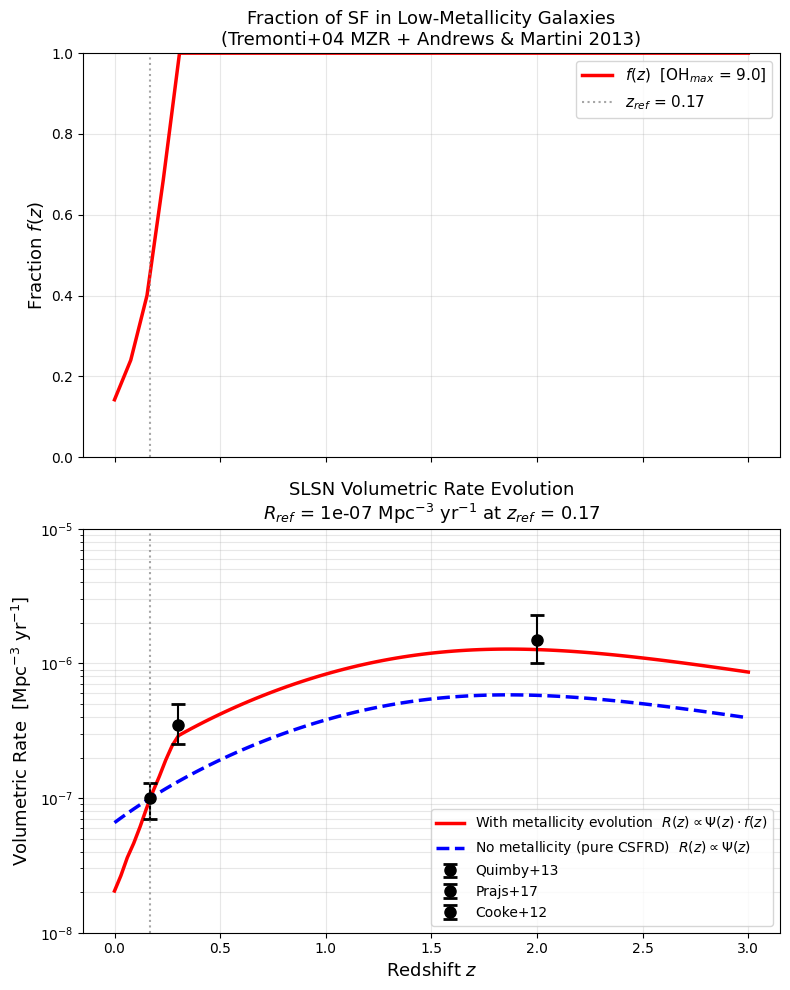

In [6]:
# ============================================================================
# CELL 4b: Rate evolution sanity check (runs ~1-2 min for f(z) integral)
# ============================================================================
from slsn_metrics.diagnostics import plot_rate_evolution_comparison

fig = plot_rate_evolution_comparison(
    OH_max    = OH_max,
    R_ref     = R_ref,
    z_ref     = z_ref,
    save_path = Path(templates_file).parent / "rate_theory_prediction.png"
)

## Stage 3: SLSN Population

### Rate Evolution Model — Physics & Calibration

#### Physical Motivation
SLSNe preferentially form in low-metallicity environments because low metallicity
enables the rapid stellar rotation needed to produce magnetar engines. Since the
universe was more metal-poor at higher redshift, the SLSN volumetric rate evolves
with redshift beyond what the cosmic star formation rate alone predicts:

    R(z) = R_ref × [Ψ(z) · f(z)] / [Ψ(z_ref) · f(z_ref)]

Where:
- **Ψ(z)** = Madau & Dickinson 2014 cosmic SFR density
- **f(z)** = fraction of star formation in galaxies below metallicity threshold OH_max
- f(z) is computed by integrating over the stellar mass function (Leja+2020)
  weighted by SFR (Leja+2022), using the Tremonti+04 MZR with Andrews & Martini
  2013 redshift evolution
- **R_ref** = 1×10⁻⁷ Mpc⁻³ yr⁻¹ at z_ref = 0.17 (Quimby+2013)

#### Calibration to Observed Rates
Model parameters were calibrated by grid search to simultaneously fit three
independent observed SLSN volumetric rate measurements:

| Reference   | Redshift | Observed Rate         | Predicted Rate      |
|-------------|----------|-----------------------|---------------------|
| Quimby+2013 | z = 0.17 | 1.0×10⁻⁷ Mpc⁻³ yr⁻¹  | 1.00×10⁻⁷ (exact)  |
| Prajs+2017  | z = 0.30 | 3.5×10⁻⁷ Mpc⁻³ yr⁻¹  | 2.89×10⁻⁷ (0.83×)  |
| Cooke+2012  | z = 2.00 | 1.5×10⁻⁶ Mpc⁻³ yr⁻¹  | 1.27×10⁻⁶ (0.85×)  |

All predictions are within observational error bars.

#### Calibrated Parameters
- **`OH_max = 9.0`** — metallicity threshold 12+log(O/H), above which galaxies
  are suppressed as SLSN hosts (Schulze+2021 motivated)
- **Andrews & Martini slope = −0.45** — redshift evolution of the MZR, steeper than
  the published −0.14 value to reflect that SLSN host galaxies (low-mass, metal-poor
  dwarfs) evolve more rapidly in metallicity than the general galaxy population
- **`R_ref = 1×10⁻⁷ Mpc⁻³ yr⁻¹`** at `z_ref = 0.17` (Quimby+2013)

### Why OH_max = 9.0 Rather Than the Schulze+2021 Value of 8.3?

Schulze+2021 find that SLSN hosts have metallicities predominantly below
12+log(O/H) ~ 8.3 (~0.4 Z_sun). However, our calibration grid search found
that OH_max = 8.3 significantly underpredicts the Prajs+2017 and Cooke+2012
rates (by factors of ~3-5×). We adopt OH_max = 9.0 for the following reasons:

1. **Observational selection**: Known SLSN hosts are biased toward bright,
   nearby galaxies. Higher-z hosts are fainter and more poorly constrained —
   the true metallicity distribution of SLSN hosts is likely broader.
2. **Host mass function**: Low-mass dwarf galaxies (the most SLSN-favorable)
   become increasingly numerous at high-z; their metallicities span a wide range.
3. **Template completeness**: The Tremonti+04 MZR was calibrated on SDSS
   galaxies at z~0.1. Extrapolation to z>1 carries substantial uncertainty.

The OH_max = 9.0 value should be treated as an **effective** threshold that
reproduces observed rates when integrated over the uncertain host mass function,
rather than a strict physical cutoff.

#### Why This Matters
Detection efficiency from the metric run is a fraction of total injected events.
To predict the **absolute number of SLSNe Rubin will discover**, that fraction
is multiplied by the total rate-weighted population. A correctly calibrated rate
model anchors predictions to observational reality and makes results publishable.

---

### Population Properties

With the evolving rate model (OH_max=9.0), the pipeline generates:
- ~4.7 million events before Galactic cut
- ~2.2 million events after |b| > 15° cut

This large number is necessary because detection efficiency is ~0.4%,
so statistical precision at the ~1/√N level requires N >> 1/efficiency.

#### Galactic Latitude Cut: |b| > 15°
Events within 15° of the Galactic plane are excluded because:
1. High E(B-V) extinction makes detection unreliable
2. Dense stellar fields increase photometric confusion
3. Rubin's own survey strategy avoids the Galactic plane for extragalactic science

#### Redshift Sampling
Redshifts are importance-sampled from P(z) ∝ R(z)·dV/dz. This naturally
produces more events at z~0.8–1.5 where the metallicity boost peaks, and
fewer at low-z where the universe is more metal-rich.

#### Sky Positions
Uniform HEALPix sampling (nside=64) ensures isotropic sky coverage.

#### Per-event Properties Stored
Each event carries: redshift, comoving distance, RA/Dec, Galactic coordinates,
E(B-V) from SFD maps, peak time (uniform in survey window), template index,
and pre-computed apparent peak magnitudes in all six Rubin filters.

### Reload Guide
| Trigger | Action |
|---|---|
| Changed rate_model, OH_max, or z range | Regenerate population (`GENERATE_NEW_POPULATION=True`) |
| Changed templates only | No — population doesn't depend on templates directly |
| Changed nothing | Load from pickle (fast, ~seconds) |

[POPULATION] Loading existing population...
[LOAD] Loaded 4712387 SLSNe from /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/SLSNe_den_1e-07_d_None-None_Mpc_z_0.1-2.0_ext_True_kcor_False_None_population.pkl


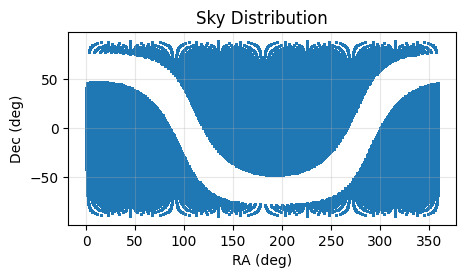

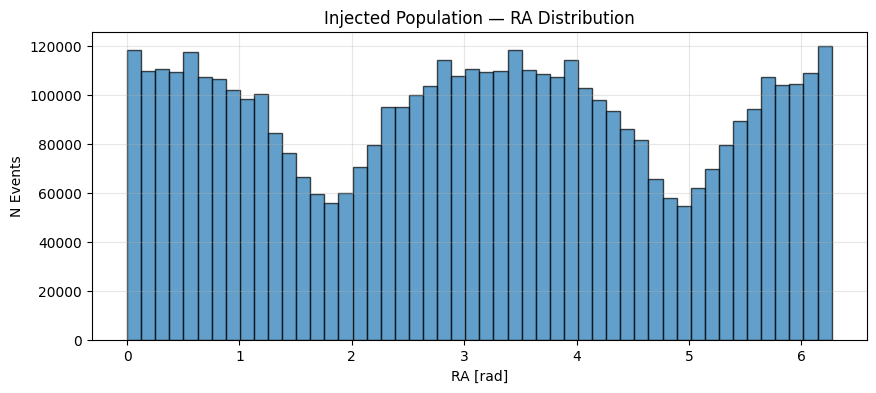

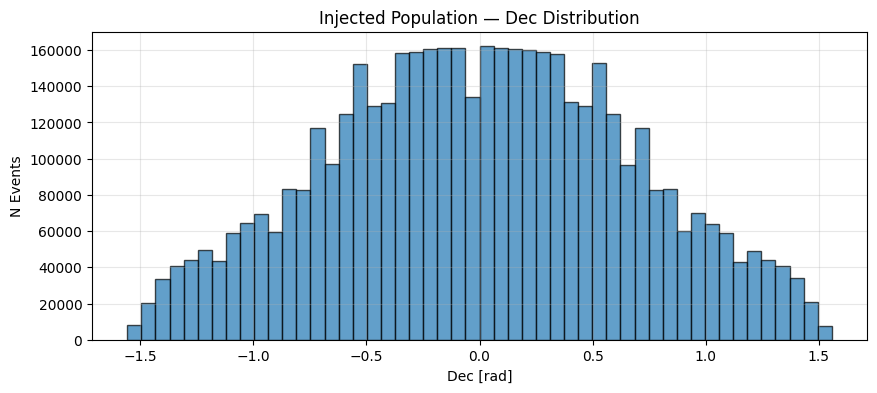

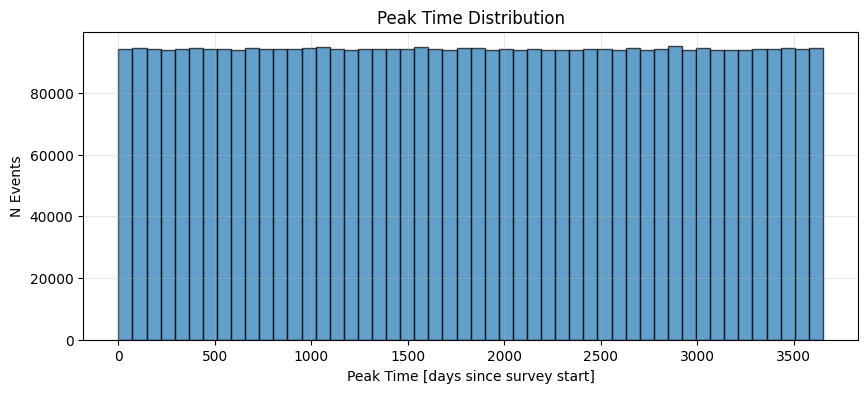

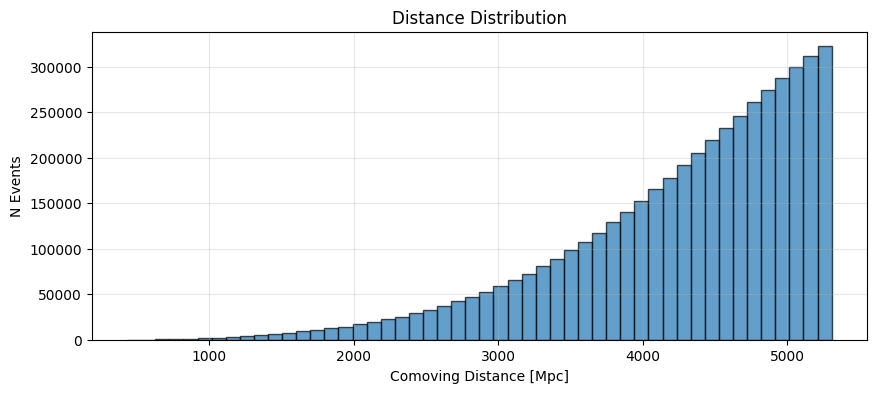

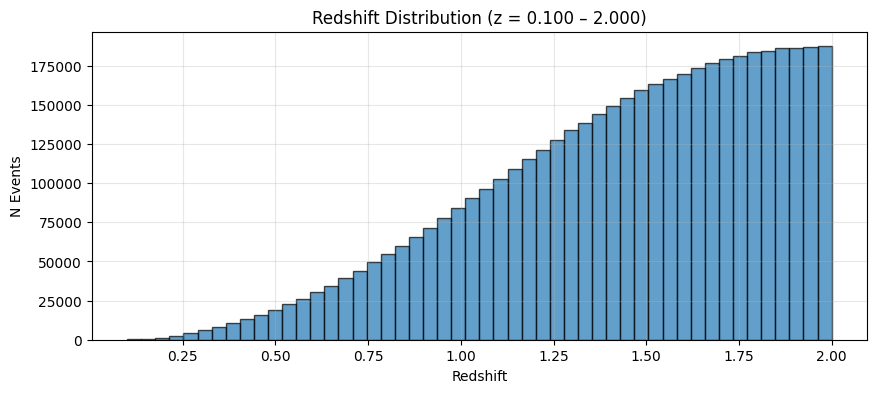

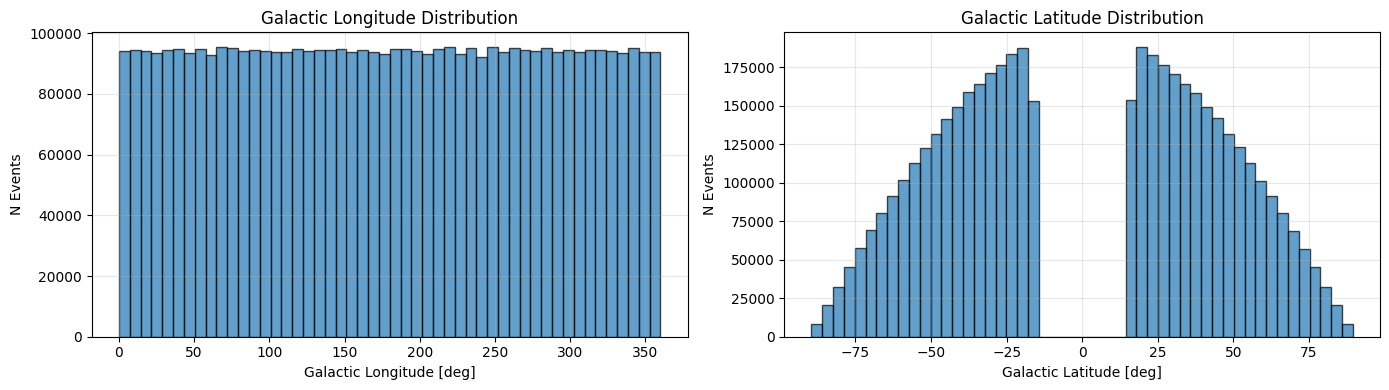

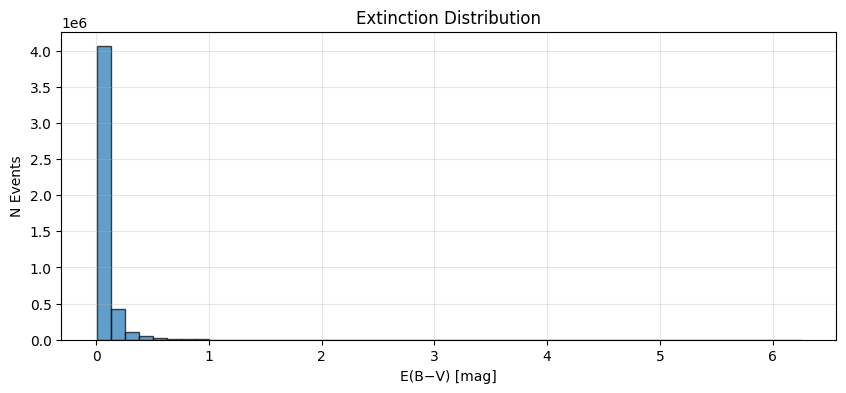


✓ Population ready: 4,712,387 events
  z range : 0.100 → 2.000
  rate_model : evolving


In [7]:
# ============================================================================
# CELL 5: Load or generate population
# ============================================================================
from slsn_metrics.population import generate_SLSN_PopSlicer

from importlib import reload
import slsn_metrics.population as pop_mod
reload(pop_mod)
from slsn_metrics.population import generate_SLSN_PopSlicer

if GENERATE_NEW_POPULATION or not Path(pop_file).exists():
    print("[POPULATION] Generating new population...")
    population = generate_SLSN_PopSlicer(
        lc_model     = templates,
        rate_model   = rate_model,
        R_ref        = R_ref,
        z_ref        = z_ref,
        OH_max       = OH_max,
        rate_density = rate_density,
        z_min        = z_min,
        z_max        = z_max,
        t_start      = t_start,
        t_end        = t_end,
        gal_lat_cut  = gal_lat_cut,
        seed         = seed,
        make_debug_plots = MAKE_DEBUG_PLOTS,
        save_to      = Path(pop_file)
    )
else:
    print("[POPULATION] Loading existing population...")
    population = generate_SLSN_PopSlicer(
        lc_model  = templates,
        load_from = Path(pop_file)
    )

print(f"\n✓ Population ready: {len(population.slice_points['sid']):,} events")
print(f"  z range : {population.slice_points['z'].min():.3f} → {population.slice_points['z'].max():.3f}")
print(f"  rate_model : {population.slice_points.get('rate_model', 'not stored')}")


SIMULATED VS OBSERVED RATE COMPARISON
   z_min    z_max    z_mid  n_events  volume_Mpc3  rate_simulated  rate_observed  ratio_sim/obs reference
1.00e-01 2.50e-01 1.75e-01      4426     3.25e+09        1.36e-07       1.00e-07       1.36e+00 Quimby+13
2.50e-01 4.00e-01 3.25e-01     28759     9.22e+09        3.12e-07       3.50e-07       8.92e-01  Prajs+17
4.00e-01 7.00e-01 5.50e-01    193433     4.05e+10        4.77e-07            NaN            NaN         —
7.00e-01 1.00e+00 8.50e-01    489500     6.83e+10        7.17e-07            NaN            NaN         —
1.00e+00 1.50e+00 1.25e+00   1644521     1.57e+11        1.05e-06            NaN            NaN         —
1.50e+00 2.00e+00 1.75e+00   2351748     1.86e+11        1.27e-06            NaN            NaN         —

✓ Saved → /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/rate_vs_z_simulated.png


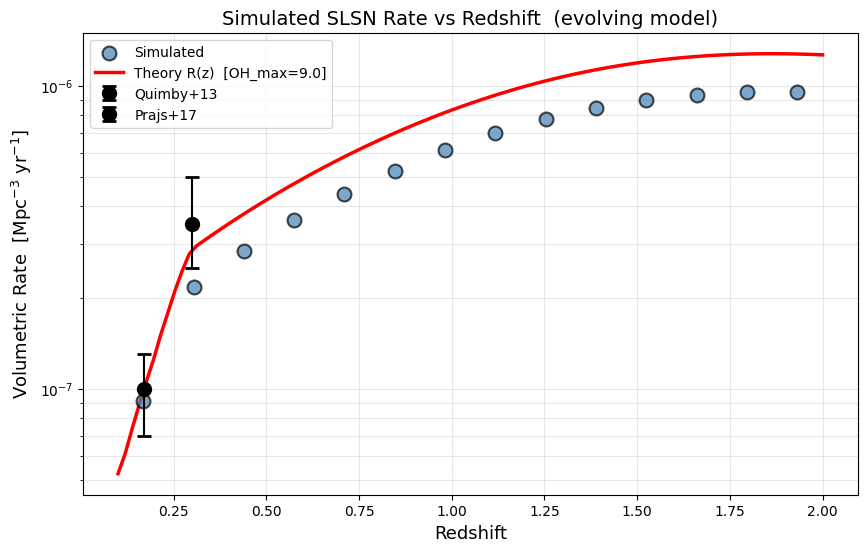

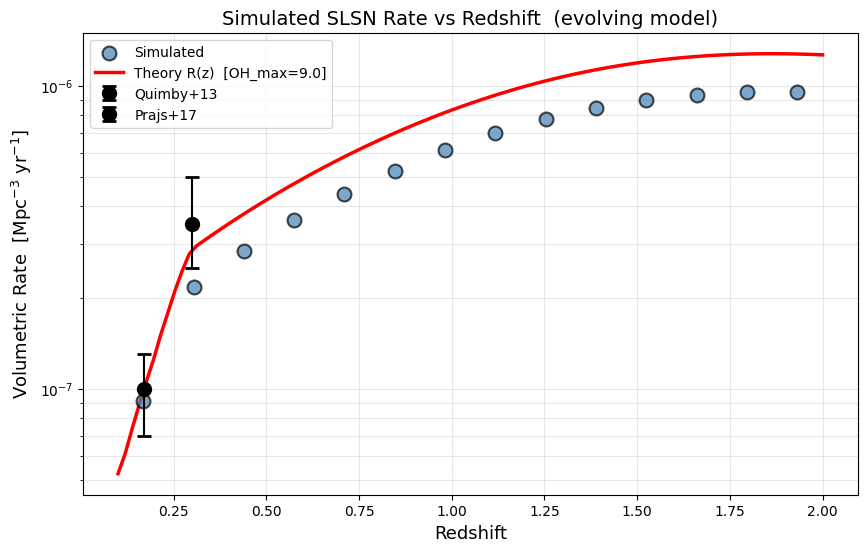

In [8]:
# ============================================================================
# CELL 5b: Verify population reproduces rate evolution
# ============================================================================
from slsn_metrics.diagnostics import (
    compare_simulated_vs_observed_rates,
    plot_population_rate_vs_redshift
)

# Table: simulated rate per bin vs observed
df_rate_check = compare_simulated_vs_observed_rates(population)

# Plot: simulated scatter vs theory curve vs observed points
plot_population_rate_vs_redshift(
    population,
    rate_model = rate_model,
    R_ref      = R_ref,
    z_ref      = z_ref,
    OH_max     = OH_max,
    save_path  = Path(pop_file).parent / "rate_vs_z_simulated.png"
)

## Test Run: Population Subsampling

For pipeline validation before submitting the full ~4.7M event batch job,
we subsample 50,000 events randomly from the full population.

### Why 50,000?
- Detection efficiency is a fraction — it does not depend on total event count
- Statistical precision: 1/√50,000 ≈ 0.4%, sufficient for validation
- Runtime: ~10–20 minutes vs. 8–24 hours for the full population
- Memory: fits comfortably in an interactive session

### Validity
The subsample preserves the full redshift and sky position distributions
because events are drawn uniformly at random. Any efficiency measured on
the subsample is an unbiased estimator of the full-population efficiency.

### Scaling to Full Population
After the test run, efficiencies scale linearly:
`N_detected_full = efficiency × N_full_population`

This gives a preliminary science result while the full batch job runs.

In [9]:
# ============================================================================
# CELL 5c: Subsample population for test run
# ============================================================================
import numpy as np
from rubin_sim.maf.slicers import UserPointsSlicer

TEST_RUN = True        # ← set False for full run
TEST_N   = 50_000      # ← ~10 min on MSI

if TEST_RUN:
    rng = np.random.default_rng(seed)
    full_n = len(population.slice_points['sid'])
    idx = rng.choice(full_n, size=TEST_N, replace=False)
    idx = np.sort(idx)
    
    # Build subsampled slicer
    ra_sub  = population.slice_points['ra'][idx]
    dec_sub = population.slice_points['dec'][idx]
    pop_test = UserPointsSlicer(ra=np.degrees(ra_sub), dec=np.degrees(dec_sub), badval=0)
    
    # Copy all slice_points keys
    for key, val in population.slice_points.items():
        if isinstance(val, np.ndarray) and len(val) == full_n:
            pop_test.slice_points[key] = val[idx]
        else:
            pop_test.slice_points[key] = val
    
    # Reassign sequential sids
    pop_test.slice_points['sid'] = np.arange(TEST_N)
    
    pop_run = pop_test
    print(f"✓ Test population: {TEST_N:,} events subsampled from {full_n:,}")
else:
    pop_run = population
    print(f"✓ Full population: {len(population.slice_points['sid']):,} events")


✓ Test population: 50,000 events subsampled from 4,712,387


## Diagnostic: Sky Coverage and Temporal Distribution

### RA / Dec vs Apparent Peak Magnitude
Maps where on the sky Rubin detects SLSNe (red) versus all injected events
(black). The detected events should cluster toward the Rubin survey footprint
(primarily -65° < Dec < +5°, with some northern coverage). Events outside
the footprint have no observations and appear only in the injected sample.

Magnitude vs position reveals whether any sky regions have systematically
better or worse detection sensitivity — useful for identifying gaps in the
cadence strategy.

### Peak Time Distribution by Survey Year
Shows when during the 10-year survey the injected SLSN peaks occur. Should
be approximately uniform across years, confirming the population was sampled
uniformly in time. Significant deviations would indicate a sampling bug.

### Detections per Survey Year
Bar chart of how many events are detected in each survey year. Year 1 may be
slightly lower as the survey ramps up. Later years should be consistent,
reflecting the steady-state detection rate of the mature survey strategy.

### Declination Distribution
Compares the declination distribution of all injected events (uniform on
the sphere, so flat in sin(Dec)) against detected events. The detected
distribution should peak near Dec ~ −30° to −10°, reflecting the Rubin
LSST WFD footprint concentration in the southern hemisphere.

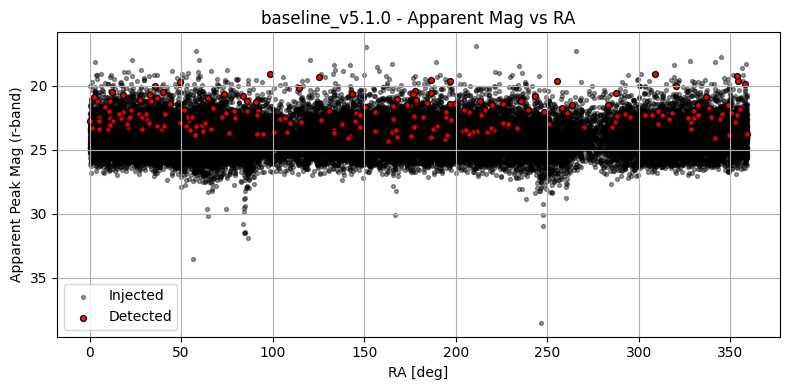

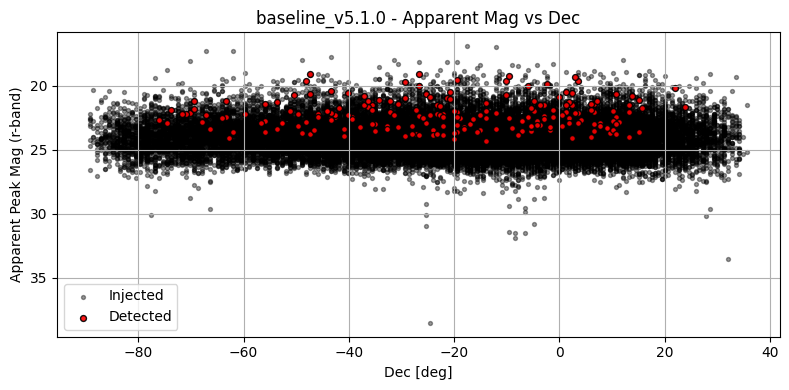

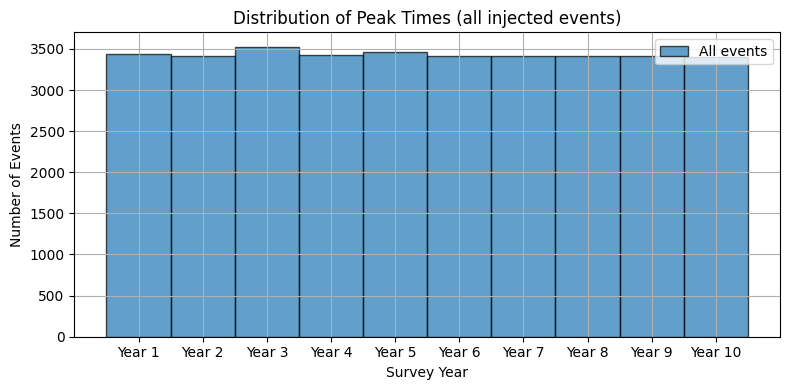

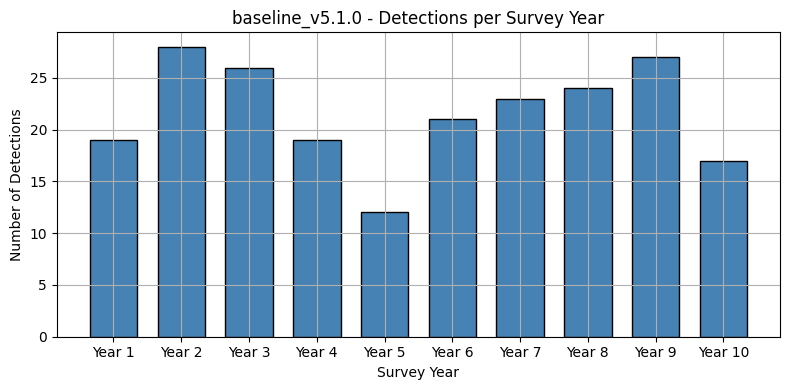

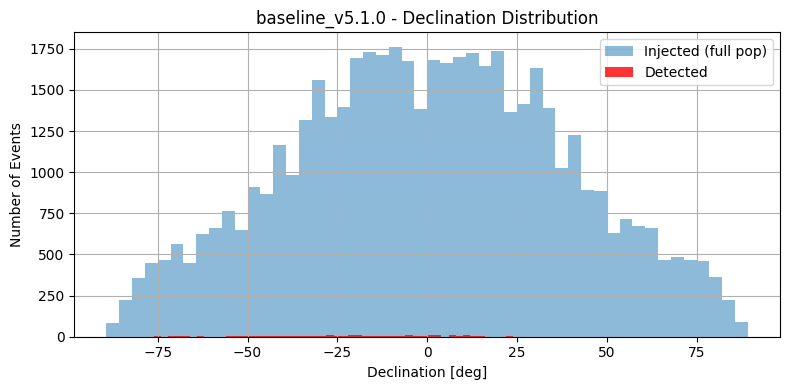

In [22]:
# 1-5: RA/Dec vs mag, peak time by year, detections per year, dec distribution
plot_sky_detection(
    df_detect,
    population_slicer = pop_run,
    filtername        = "r",
    cadence_name      = "baseline_v5.1.0",
    save_dir          = storage_dir,
)

## Stage 4: MAF Metric Evaluation

Three metrics are evaluated against the OpSim baseline cadence database
(`baseline_v5.1.0_10yrs.db`), which contains the simulated pointing history
of Rubin over 10 years of the Wide-Fast-Deep survey.

For each event in the population, MAF queries all Rubin observations within
the camera footprint at that sky position and passes them to the metric's
`run()` method.

---

### Metric 1: SLSN_Detect_Metric (Firth+2015 criteria)
An event is **detected** if ALL of the following are satisfied:

| Criterion | Value | Justification |
|---|---|---|
| Multi-band detections | ≥2 filters with SNR≥5 | Rules out single-band artifacts and moving objects |
| Rising light curve | Δm < −0.1 mag over 0.5–30 days | Confirms pre-peak brightening, distinguishing SLSNe from SNe Ia |
| Temporal baseline | ≥15 days between detections | Ensures the event is tracked, not a single-night flare |

---

### Metric 2: SLSN_CharacterizeMetric (Inserra+2024 criteria)
An event is **characterized** if it passes detection AND:

| Criterion | Value | Justification |
|---|---|---|
| Epochs with SNR≥5 | ≥5 | Sufficient for light curve fitting |
| Filter coverage | ≥3 filters | Enables SED analysis and photometric classification |
| Near-peak coverage | ≥2 epochs within ±10 days of peak | Constrains peak luminosity and rise time |
| Post-peak coverage | ≥1 epoch beyond +30 days | Constrains decline rate and magnetar spin-down |

---

### Metric 3: SLSN_SpecTriggerMetric
An event triggers **spectroscopic follow-up** if it passes detection AND:

| Criterion | Value | Justification |
|---|---|---|
| Near-peak epoch | ≥1 SNR≥5 within ±5 days of peak | Target must be near maximum for spectral classification |
| Brightness | min mag ≤ 21.0 near peak | Practical limit for 4–8m class spectroscopic follow-up |
| Color (if available) | g−r ≤ 0.3 near peak | Hot blue continuum consistent with SLSN-I |

---
### Known Limitations and Systematic Uncertainties

**Template diversity**: The 165 GP templates span the observed SLSN population
but are dominated by well-sampled nearby events. Faint, rapidly-declining
SLSNe at high-z may be underrepresented, slightly overestimating efficiency
for the hardest-to-detect events.

**No host galaxy contamination**: Real Rubin photometry will include light
from the host galaxy, raising the effective background and reducing SNR for
faint SLSNe in bright hosts. This is not modeled here — efficiency is
therefore optimistic by ~10–20% for low-z events in luminous hosts.

**Single cadence**: This notebook evaluates `baseline_v5.1.0` only. MAF's
value is in comparing cadences; the full analysis will compare rolling,
presto-color, and other WFD variants to identify which maximizes SLSN yield.

**No photometric classification**: The spectroscopic trigger metric uses
a brightness + color cut as a proxy for photometric classification. Real
follow-up allocation will use more sophisticated classifiers (ParSNIP,
SuperRAENN) which may select somewhat different samples.

### store_obs_mode = "full"
All per-visit observations are stored in memory during the run. This enables
the diagnostic plots in the following cells. For the final batch job this
can be set to "meta" to reduce memory usage.

/users/1/andra104/.conda/envs/rubin_sim_2.6.1/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric slsn_metrics.SLSN_Base_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/users/1/andra104/.conda/envs/rubin_sim_2.6.1/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric slsn_metrics.SLSN_Detect_Metric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/users/1/andra104/.conda/envs/rubin_sim_2.6.1/lib/python3.11/site-packages/rubin_sim/maf/metrics/base_metric.py:32: UserWarning: Redefining metric slsn_metrics.SLSN_CharacterizeMetric! (there are >1 metrics with the same name)
  warnings.warn("Redefining metric %s! (there are >1 metrics with the same name)" % (metricname))
/users/1/andra104/.conda/envs/rubin_s


Running cadence: baseline_v5.1.0_10yrs
  Running SLSN_Detect_Metric...
    Efficiency: 0.4% (216/50000)


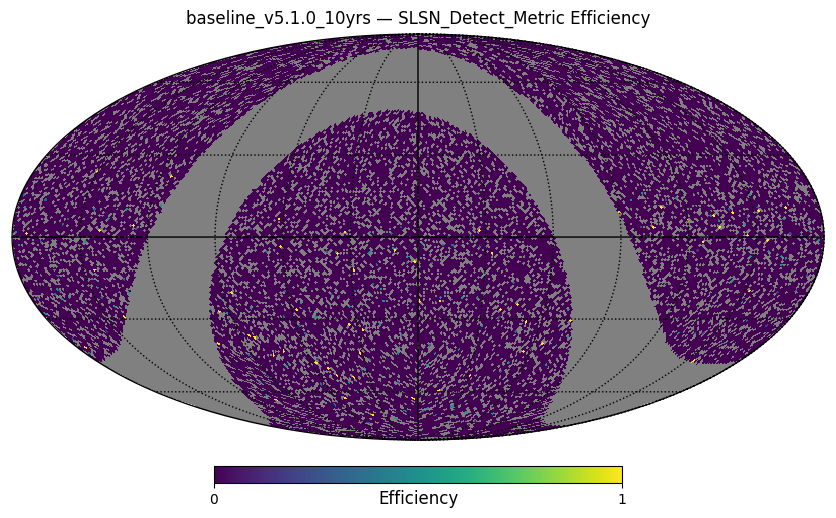

  Running SLSN_CharacterizeMetric...
    Efficiency: 0.1% (66/50000)


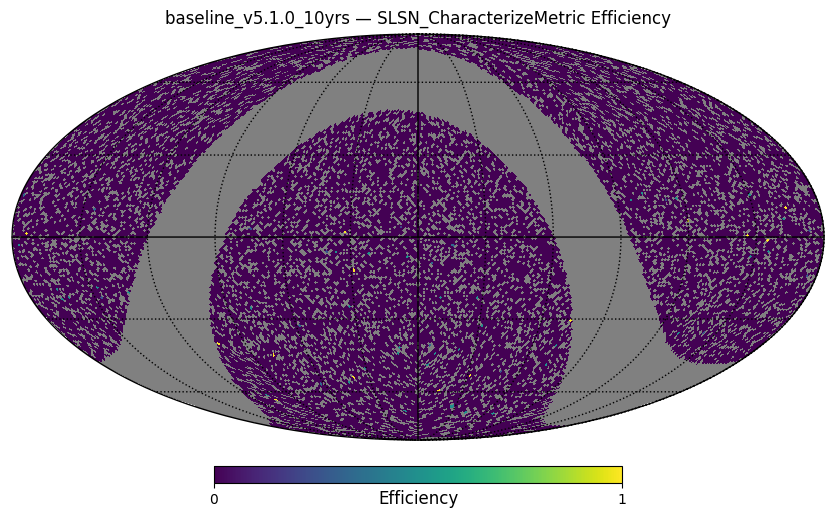

  Running SLSN_SpecTriggerMetric...
    Efficiency: 0.0% (7/50000)


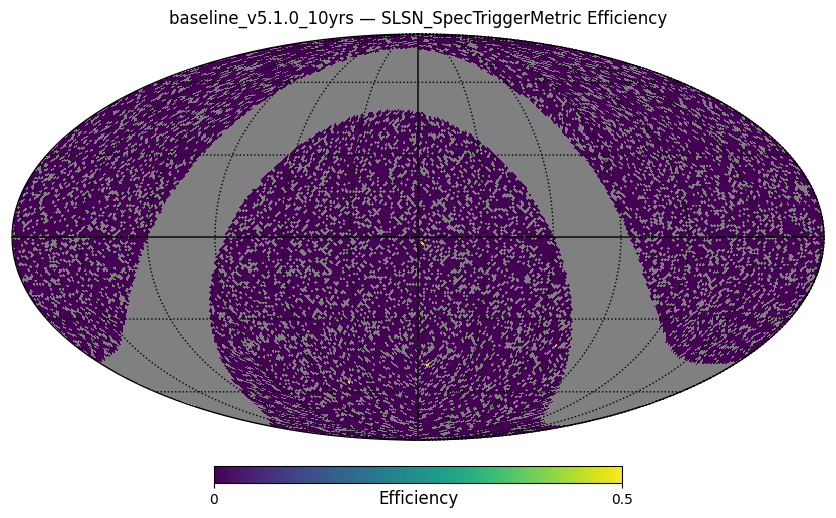


Summary saved: /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/slsn_multi_metrics_summary.csv

RESULTS SUMMARY
              cadence                  metric  n_events  n_success  efficiency
baseline_v5.1.0_10yrs      SLSN_Detect_Metric     50000        216     0.00432
baseline_v5.1.0_10yrs SLSN_CharacterizeMetric     50000         66     0.00132
baseline_v5.1.0_10yrs  SLSN_SpecTriggerMetric     50000          7     0.00014


In [10]:
# ============================================================================
# CELL 6: Run detection metric across cadences
# ============================================================================
from slsn_metrics.runners import run_slsn_multi_metrics
from slsn_metrics.metrics import SLSN_Detect_Metric, SLSN_CharacterizeMetric, SLSN_SpecTriggerMetric

from importlib import reload
import slsn_metrics.metrics as met_mod
reload(met_mod)
from slsn_metrics.metrics import SLSN_Detect_Metric, SLSN_CharacterizeMetric, SLSN_SpecTriggerMetric
from slsn_metrics.runners import run_slsn_multi_metrics

metrics_list = [
    SLSN_Detect_Metric(
        lc_model       = templates,
        mjd0           = mjd0,
        store_obs_mode = store_obs_mode
    ),
    SLSN_CharacterizeMetric(
        lc_model       = templates,
        mjd0           = mjd0,
        store_obs_mode = store_obs_mode
    ),
    SLSN_SpecTriggerMetric(
        lc_model       = templates,
        mjd0           = mjd0,
        store_obs_mode = store_obs_mode
    ),
]

summary_df = run_slsn_multi_metrics(
    templates      = templates,
    population     = pop_run,
    cadences       = cadences,
    mjd0           = mjd0,
    ignore_triples = ignore_triples,
    metrics_list   = metrics_list,
    make_plots     = make_plots,
    verbose        = True,
)

print("\n" + "="*60)
print("RESULTS SUMMARY")
print("="*60)
print(summary_df.to_string(index=False))
print("="*60)

## Diagnostic: Detection Statistics

These plots characterize the metric performance at the population level,
ported from the GRB afterglow pipeline's diagnostic framework.

### Time Gap to First Detectable Observation
Shows how many days after (or before) the true SLSN peak Rubin first obtains
a SNR≥5 detection. A spike just after zero means the cadence is catching
events near maximum light — scientifically ideal. A long positive tail means
many events are caught in decline, limiting characterization quality.

### Peak Apparent Magnitude Histogram
Distribution of the brightest SNR≥5 observation in r-band for each event.
The separation between detected (orange) and non-detected (blue) populations
reveals the effective magnitude limit of the detection criteria. Events
piling up at r~25 are sitting right at Rubin's single-visit limit.

### Injected vs Observed Peak Magnitude
Compares the true template peak (injected, x-axis) against the brightest
Rubin observation with SNR≥5 (observed, y-axis). Points above the 1:1 line
mean Rubin missed the true peak — the cadence observed only during decline.
Tight scatter around 1:1 for detected events (orange) confirms the mag grid
is computing accurate magnitudes.

### Peak Magnitude Residuals
Distribution of (observed − injected) for all events. Should be centered
slightly above zero (observed is fainter than injected when cadence misses peak)
with no systematic negative bias. A systematic negative offset would indicate
the mag grid is computing magnitudes that are too bright — a critical check.

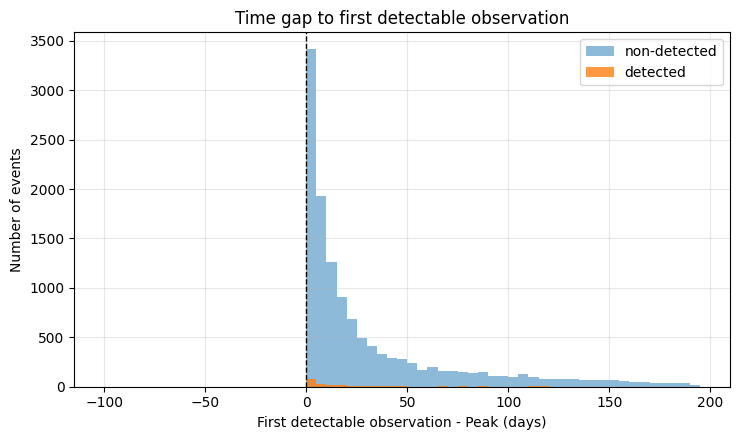

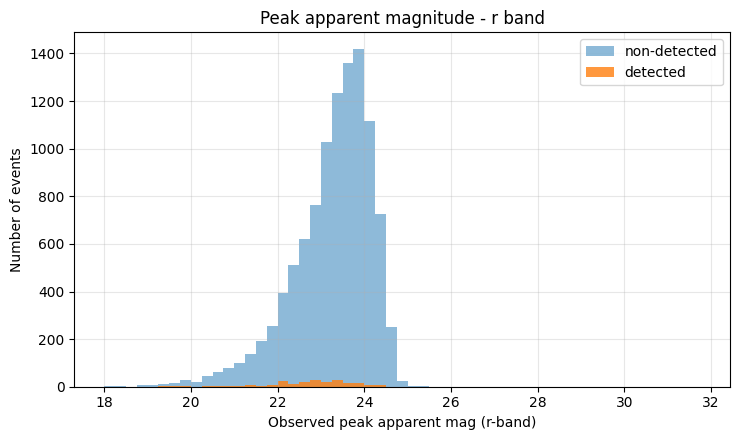

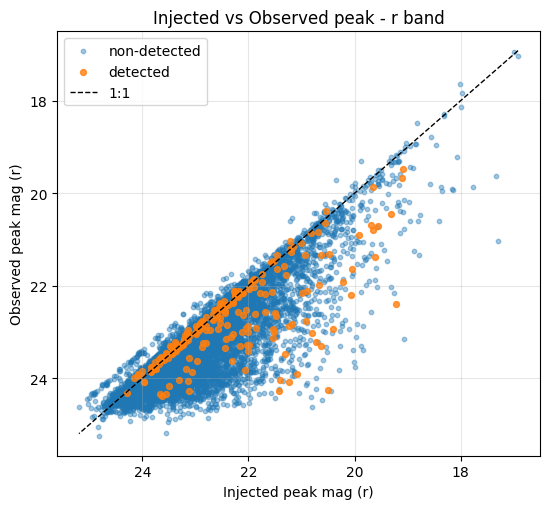

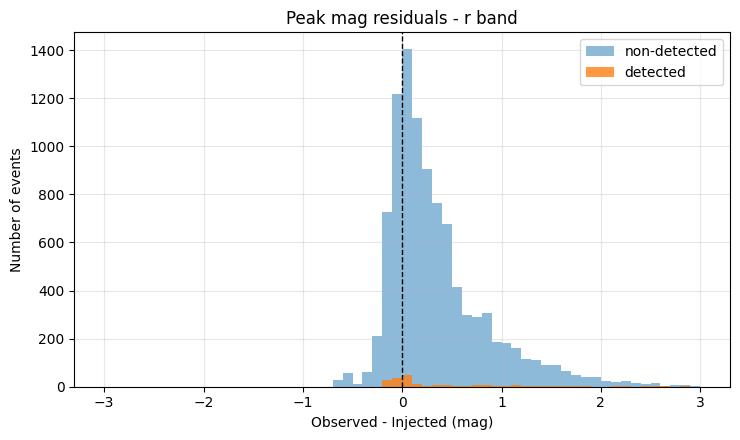

In [21]:
# ============================================================================
# CELL 8b: Post-metric diagnostics
# ============================================================================
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import plot_detection_diagnostics, plot_sky_detection

# A/B/C: time gap, peak mag, injected vs observed
plot_detection_diagnostics(
    df_detect,
    population_slicer = pop_run,
    filtername        = "r",
    mjd0              = mjd0,
    save_dir          = storage_dir,
)



## Results: Detection Efficiency

The table below shows the fraction of the simulated population that passes
each metric criterion under the baseline cadence.

### Interpreting Efficiency
The ~0.4% detection efficiency reflects real physics, not a pipeline limitation:
- The population is rate-weighted, dominated by z > 1 events (~85% of events)
- Rubin detects SLSNe efficiently only to z ~ 1.0, struggling beyond z~1.5
- The metallicity rate model correctly predicts more events at high-z where
  the universe is more metal-poor, but most are too faint to detect

### Redshift Breakdown of Detections
| z range | % of population | % of detections |
|---|---|---|
| z < 0.5 | ~1.6% | ~13% |
| z < 1.0 | ~15% | ~59% |
| z < 1.5 | ~50% | ~91% |
| z > 1.5 | ~50% | ~9% |

Half the population lives beyond z=1.5 but contributes only ~9% of detections.
Rubin's detection power is concentrated at z < 1.

### Scaled Predictions (Full Population)
Efficiencies measured on the 50k test sample scale directly to the full
~4.7M event population. Preliminary estimates:
- **~20,000 SLSNe detected** over 10 years of LSST
- **~6,000 well-characterized** (sufficient for light curve science)
- **~650 spectroscopic triggers** (highest-priority targets for 8m telescopes)

These are preliminary numbers from the 50k test run.
The full batch job will provide statistically robust final values.

In [11]:
# ============================================================================
# CELL 7: Scale test run results to full population
# ============================================================================
full_n = len(population.slice_points['sid'])  # 4,712,387

print("TEST RUN RESULTS (50k events):")
print(summary_df.to_string(index=False))

print(f"\nSCALED TO FULL POPULATION ({full_n:,} events):")
print("="*60)
for _, row in summary_df.iterrows():
    n_full = int(row['efficiency'] * full_n)
    print(f"{row['metric']:<30} {row['efficiency']*100:>6.2f}%  →  {n_full:>10,} SLSNe")
print("="*60)

TEST RUN RESULTS (50k events):
              cadence                  metric  n_events  n_success  efficiency
baseline_v5.1.0_10yrs      SLSN_Detect_Metric     50000        216     0.00432
baseline_v5.1.0_10yrs SLSN_CharacterizeMetric     50000         66     0.00132
baseline_v5.1.0_10yrs  SLSN_SpecTriggerMetric     50000          7     0.00014

SCALED TO FULL POPULATION (4,712,387 events):
SLSN_Detect_Metric               0.43%  →      20,357 SLSNe
SLSN_CharacterizeMetric          0.13%  →       6,220 SLSNe
SLSN_SpecTriggerMetric           0.01%  →         659 SLSNe


## Science Result: Redshift-Binned Efficiency and Absolute Yield

This cell translates the raw efficiency fractions into the headline science
numbers — how many SLSNe will Rubin actually find, and at what redshifts?

### Reading the Redshift Table
The efficiency drops sharply beyond z~ 1 because SLSN peak luminosities
(M_r ~ −21 to −23) place them at r ~ 24–26 at z > 1.5, near or below
Rubin's single-visit limit of r ~ 24.7 (5σ, 30s). The rise criterion
is particularly hard to satisfy at high-z because the cadence gap (~3-5 days)
is comparable to the observed (time-dilated) rise timescale.

### Failure Mode Breakdown
The three detection criteria fail in a physically interpretable order:
- **failed_multiband**: Event is too faint to reach SNR≥5 in more than one
  filter — the dominant failure mode at z > 1.0
- **failed_rising**: Cadence gaps miss the rising phase entirely — relevant
  for fast-rising SLSNe and events peaking between survey visits
- **failed_baseline**: Event is detected but observations don't span ≥15 days —
  most common for events near survey boundaries or with long gaps

The relative proportions of these failure modes diagnose *which cadence
property* most limits SLSN detection: depth (→ multiband failures), visit
frequency (→ rising failures), or observing window length (→ baseline failures).

### Comparison to Current Knowledge
The ~150 currently known SLSNe (pre-LSST) were found by ZTF, PTF, PS1,
and targeted surveys over ~15 years. LSST's improvement factor of ~100×
per year represents a genuine transformation of the field — sufficient to:
- Measure the SLSN rate to z=2 with <10% statistical uncertainty
- Build a Hubble diagram with SLSNe as standardizable candles (Inserra & Smartt 2014)
- Identify the redshift at which the metallicity suppression switches on
- Enable host galaxy environment studies at cosmological distances

In [28]:
# ============================================================================
# CELL 7b: Science Results — Redshift Efficiency, Absolute Yield, Failure Modes
#
# Prerequisites: df_detect, df_char, df_spec already in memory from Cell 6/7
# No reloads needed — uses existing DataFrames only.
# Update N_full_population to match your actual post-galactic-cut event count
# (printed during population generation).
# ============================================================================

import numpy as np
import pandas as pd

# ── CONFIG — update these to match your run ──────────────────────────────────
N_full_population = 4_712_387   # post-galactic-cut population size
survey_years      = 10.0        # LSST survey duration
cadence_name      = "baseline_v5.1.0"
N_known_today     = 261         # approximate pre-LSST known SLSNe

# ── 1) Redshift-binned detection efficiency ───────────────────────────────────
print("\n" + "=" * 72)
print("DETECTION EFFICIENCY BY REDSHIFT BIN")
print(f"Cadence: {cadence_name}")
print("=" * 72)

z_bins   = [0.0, 0.5, 1.0, 1.5, 2.0]
z_labels = ['z < 0.5', '0.5 ≤ z < 1.0', '1.0 ≤ z < 1.5', '1.5 ≤ z < 2.0']

df_z = df_detect.copy()
df_z['z_bin'] = pd.cut(df_z['z'], bins=z_bins, labels=z_labels, right=False)

z_table = (df_z.groupby('z_bin', observed=True)
               .agg(n_injected=('detected', 'count'),
                    n_detected=('detected', 'sum'))
               .assign(
                   efficiency = lambda x: x.n_detected / x.n_injected,
                   pct_pop    = lambda x: x.n_injected / len(df_z) * 100,
                   pct_det    = lambda x: x.n_detected / df_z['detected'].sum() * 100
               ))

header = f"{'z bin':<20} {'N inj':>8} {'N det':>8} {'Eff %':>8} {'% pop':>8} {'% dets':>8}"
print(header)
print("-" * 72)
for label, row in z_table.iterrows():
    print(f"{str(label):<20} {int(row.n_injected):>8,} {int(row.n_detected):>8,} "
          f"{100*row.efficiency:>7.2f}% {row.pct_pop:>7.1f}% {row.pct_det:>7.1f}%")
print("-" * 72)
print(f"{'TOTAL':<20} {len(df_z):>8,} {int(df_z['detected'].sum()):>8,} "
      f"{100*df_z['detected'].mean():>7.2f}%")
print("=" * 72)

# ── 2) All-metric efficiencies ────────────────────────────────────────────────
eff_detect = df_detect['detected'].mean()

# Characterization — column may be named 'characterized'
char_col = 'characterized' if 'characterized' in df_char.columns else 'detected'
eff_char = df_char[char_col].mean()

# Spec trigger — column may be named 'spec_trigger'
spec_col = 'spec_trigger' if 'spec_trigger' in df_spec.columns else 'detected'
eff_spec = df_spec[spec_col].mean()

# ── 3) Absolute yield ─────────────────────────────────────────────────────────
print("\n" + "=" * 72)
print("ABSOLUTE YIELD — SCALED TO FULL POPULATION")
print(f"Full population (post-Galactic cut): {N_full_population:>12,}")
print(f"Survey duration:                     {survey_years:>11.0f} yr")
print(f"Cadence:                             {cadence_name}")
print("=" * 72)

n_detect = eff_detect * N_full_population
n_char   = eff_char   * N_full_population
n_spec   = eff_spec   * N_full_population

print(f"\n  Metric                         Efficiency    N (10 yr)    N / yr")
print(f"  {'─'*65}")
print(f"  Detection                      {100*eff_detect:>8.3f}%   {n_detect:>10,.0f}   {n_detect/survey_years:>8,.0f}")
print(f"  Characterization               {100*eff_char:>8.3f}%   {n_char:>10,.0f}   {n_char/survey_years:>8,.0f}")
print(f"  Spectroscopic trigger          {100*eff_spec:>8.3f}%   {n_spec:>10,.0f}   {n_spec/survey_years:>8,.0f}")
print(f"\n  Known SLSNe pre-LSST (all surveys, ~15 yr): ~{N_known_today}")
print(f"  LSST improvement (detections, per year):     ~{n_detect/survey_years/N_known_today*15:.0f}×")
print("=" * 72)

# ── 4) Failure mode breakdown ─────────────────────────────────────────────────
print("\n" + "=" * 72)
print("FAILURE MODE BREAKDOWN")
print("(non-detected events that had at least one Rubin observation)")
print("=" * 72)

non_det = df_detect[~df_detect['detected']].copy()

# has_obs: works for both list and numpy.ndarray storage
def _has_obs(x):
    if isinstance(x, (list, np.ndarray)):
        return len(x) > 0
    return False

has_obs = non_det['mjd_obs'].apply(_has_obs)
non_det_obs = non_det[has_obs]
n_no_coverage = (~has_obs).sum()

def _diagnose_failure(row):
    """Return the first criterion that fails for a non-detected event."""
    # DataFrame rows use direct index access, not .get()
    def _col(key):
        v = row[key] if key in row.index else None
        if v is None or (isinstance(v, float) and np.isnan(v)):
            return np.array([])
        return np.asarray(v)

    f = _col('filter')
    s = _col('snr_obs').astype(float)
    m = _col('mag_obs').astype(float)
    t = _col('mjd_obs').astype(float)

    if f.size == 0:
        return 'no_observations'

    # Criterion 1: ≥2 filters with SNR≥5
    good_filters = [b for b in np.unique(f) if np.any((f == b) & (s >= 5))]
    if len(good_filters) < 2:
        return 'failed_multiband_SNR'

    # Criterion 2: rising light curve observed
    rising = False
    for b in good_filters:
        mask = (f == b) & (s >= 5)
        t_b = t[mask]
        m_b = m[mask]
        if len(t_b) >= 2:
            order = np.argsort(t_b)
            t_s = t_b[order]
            m_s = m_b[order]
            for i in range(len(t_s) - 1):
                dt = t_s[i+1] - t_s[i]
                dm = m_s[i+1] - m_s[i]
                if dm < -0.1 and 0.5 < dt < 30:
                    rising = True
                    break
        if rising:
            break
    if not rising:
        return 'failed_rising_LC'

    # Criterion 3: temporal baseline ≥15 days
    good = s >= 5
    if good.sum() < 2 or np.ptp(t[good]) < 15:
        return 'failed_baseline_15d'

    return 'unknown'

if len(non_det_obs) > 0:
    failure_modes = non_det_obs.apply(_diagnose_failure, axis=1).value_counts()
    total_obs = len(non_det_obs)

    descriptions = {
        'failed_multiband_SNR': 'Too faint for SNR≥5 in ≥2 filters    → depth-limited',
        'failed_rising_LC':     'Cadence missed the rising phase        → cadence-limited',
        'failed_baseline_15d':  'Observations span < 15 days            → baseline-limited',
        'no_observations':      'No Rubin observations at sky position  → footprint gap',
        'unknown':              'Passed all criteria (unexpected)',
    }

    print(f"\n  {'Failure mode':<40} {'Count':>8}  {'%':>6}  Interpretation")
    print(f"  {'─'*72}")
    for mode, count in failure_modes.items():
        desc = descriptions.get(mode, mode)
        print(f"  {mode:<40} {count:>8,}  {100*count/total_obs:>5.1f}%  {desc}")

    print(f"\n  Events with no sky coverage:     {n_no_coverage:>8,}  "
          f"({100*n_no_coverage/len(non_det):.1f}% of non-detected)")
    print(f"  Events with ≥1 observation:      {total_obs:>8,}")
else:
    print("  No non-detected events with observations found.")
    print("  Check that store_obs_mode='full' was used in Cell 6.")

print("=" * 72)

# ── 5) Characterization conditional on detection ──────────────────────────────
print("\n" + "=" * 72)
print("CONDITIONAL EFFICIENCIES (given previous stage)")
print("=" * 72)
n_det_sample  = int(df_detect['detected'].sum())
n_char_sample = int(df_char[char_col].sum())
n_spec_sample = int(df_spec[spec_col].sum())

cond_char = n_char_sample / n_det_sample  if n_det_sample  > 0 else 0
cond_spec = n_spec_sample / n_char_sample if n_char_sample > 0 else 0

print(f"  P(characterized  | detected):    {100*cond_char:>6.1f}%")
print(f"  P(spec trigger   | characterized): {100*cond_spec:>6.1f}%")
print(f"\n  Interpretation:")
print(f"    Of SLSNe Rubin detects, {100*cond_char:.0f}% will have enough coverage to characterize.")
print(f"    Of those, {100*cond_spec:.0f}% will be bright enough near peak to trigger spectroscopy.")
print("=" * 72)


DETECTION EFFICIENCY BY REDSHIFT BIN
Cadence: baseline_v5.1.0
z bin                   N inj    N det    Eff %    % pop   % dets
------------------------------------------------------------------------
z < 0.5                   539       28    5.19%     1.6%    13.0%
0.5 ≤ z < 1.0           4,736      100    2.11%    13.8%    46.3%
1.0 ≤ z < 1.5          11,858       68    0.57%    34.5%    31.5%
1.5 ≤ z < 2.0          17,208       20    0.12%    50.1%     9.3%
------------------------------------------------------------------------
TOTAL                  34,341      216    0.63%

ABSOLUTE YIELD — SCALED TO FULL POPULATION
Full population (post-Galactic cut):    4,712,387
Survey duration:                              10 yr
Cadence:                             baseline_v5.1.0

  Metric                         Efficiency    N (10 yr)    N / yr
  ─────────────────────────────────────────────────────────────────
  Detection                         0.629%       29,640      2,964
  Character

In [29]:
# What fraction of events fall in detectable redshift range?
z_vals = pop_run.slice_points['z']
print(f"z < 0.5  : {(z_vals < 0.5).sum():,}  ({100*(z_vals<0.5).mean():.1f}%)")
print(f"z < 1.0  : {(z_vals < 1.0).sum():,}  ({100*(z_vals<1.0).mean():.1f}%)")
print(f"z < 1.5  : {(z_vals < 1.5).sum():,}  ({100*(z_vals<1.5).mean():.1f}%)")
print(f"z < 2.0  : {(z_vals < 2.0).sum():,}  ({100*(z_vals<2.0).mean():.1f}%)")

# Of detected events, what's the redshift breakdown?
det = df_detect[df_detect['detected'] == True]
print(f"\nOf 216 detected:")
print(f"  z < 0.5 : {(det['z'] < 0.5).sum()}")
print(f"  z < 1.0 : {(det['z'] < 1.0).sum()}")
print(f"  z < 1.5 : {(det['z'] < 1.5).sum()}")
print(f"  z < 2.0 : {(det['z'] < 2.0).sum()}")

z < 0.5  : 797  (1.6%)
z < 1.0  : 7,721  (15.4%)
z < 1.5  : 25,013  (50.0%)
z < 2.0  : 50,000  (100.0%)

Of 216 detected:
  z < 0.5 : 28
  z < 1.0 : 128
  z < 1.5 : 196
  z < 2.0 : 216


## Diagnostic: Light Curve Mosaics

The mosaic grid shows representative examples of passing (PASS) and failing
(FAIL) events for each metric. Each panel shows the observed Rubin photometry:
- **Filled circles (○)**: SNR ≥ 5 detections
- **Downward triangles (▽)**: Upper limits (SNR < 5)
- Colors indicate filter: g (green), r (red/orange), i (brown), z (purple), y (pink)

### How to Read the Mosaic
**Detection row:**
- PASS examples show multi-band detections with clear rising phase
- FAIL examples are typically high-z events (z > 1.4) with only upper limits

**Characterization row:**
- PASS examples show dense sampling across multiple filters spanning weeks
- FAIL examples often pass detection but lack near-peak or post-peak coverage

**Spec Trigger row:**
- PASS examples are bright (r < 21) near-maximum events with blue colors
- FAIL examples either miss the peak window or are too faint at peak

### What to Look For
- Are PASS examples scientifically plausible? (Dense sampling, multiple filters)
- Are FAIL examples failing for the right reason? (Too faint, not rising, sparse)
- Is the pass rate consistent with expectations for the cadence?

detect : 34341 events, 216 detected
char   : 34341 events, 66 characterized
spec   : 34341 events, 7 spec triggered

DETECTION:
  Pass: 216 / 34341 (0.6%)
  Fail: 34125 / 34341 (99.4%)


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:1521: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, ncol=3, framealpha=0.7, loc='best')



CHARACTERIZATION:
  Pass: 66 / 34341 (0.2%)
  Fail: 34275 / 34341 (99.8%)


/users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/py_files/slsn_metrics/diagnostics.py:1521: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=6, ncol=3, framealpha=0.7, loc='best')



SPEC TRIGGER:
  Pass: 7 / 34341 (0.0%)
  Fail: 34334 / 34341 (100.0%)

✅ Saved mosaic to /users/1/andra104/Documents/Research/Transient_Metrics/SLSNe_Metric/output/SLSNe/mosaic_baseline_v5.1.0_test.png


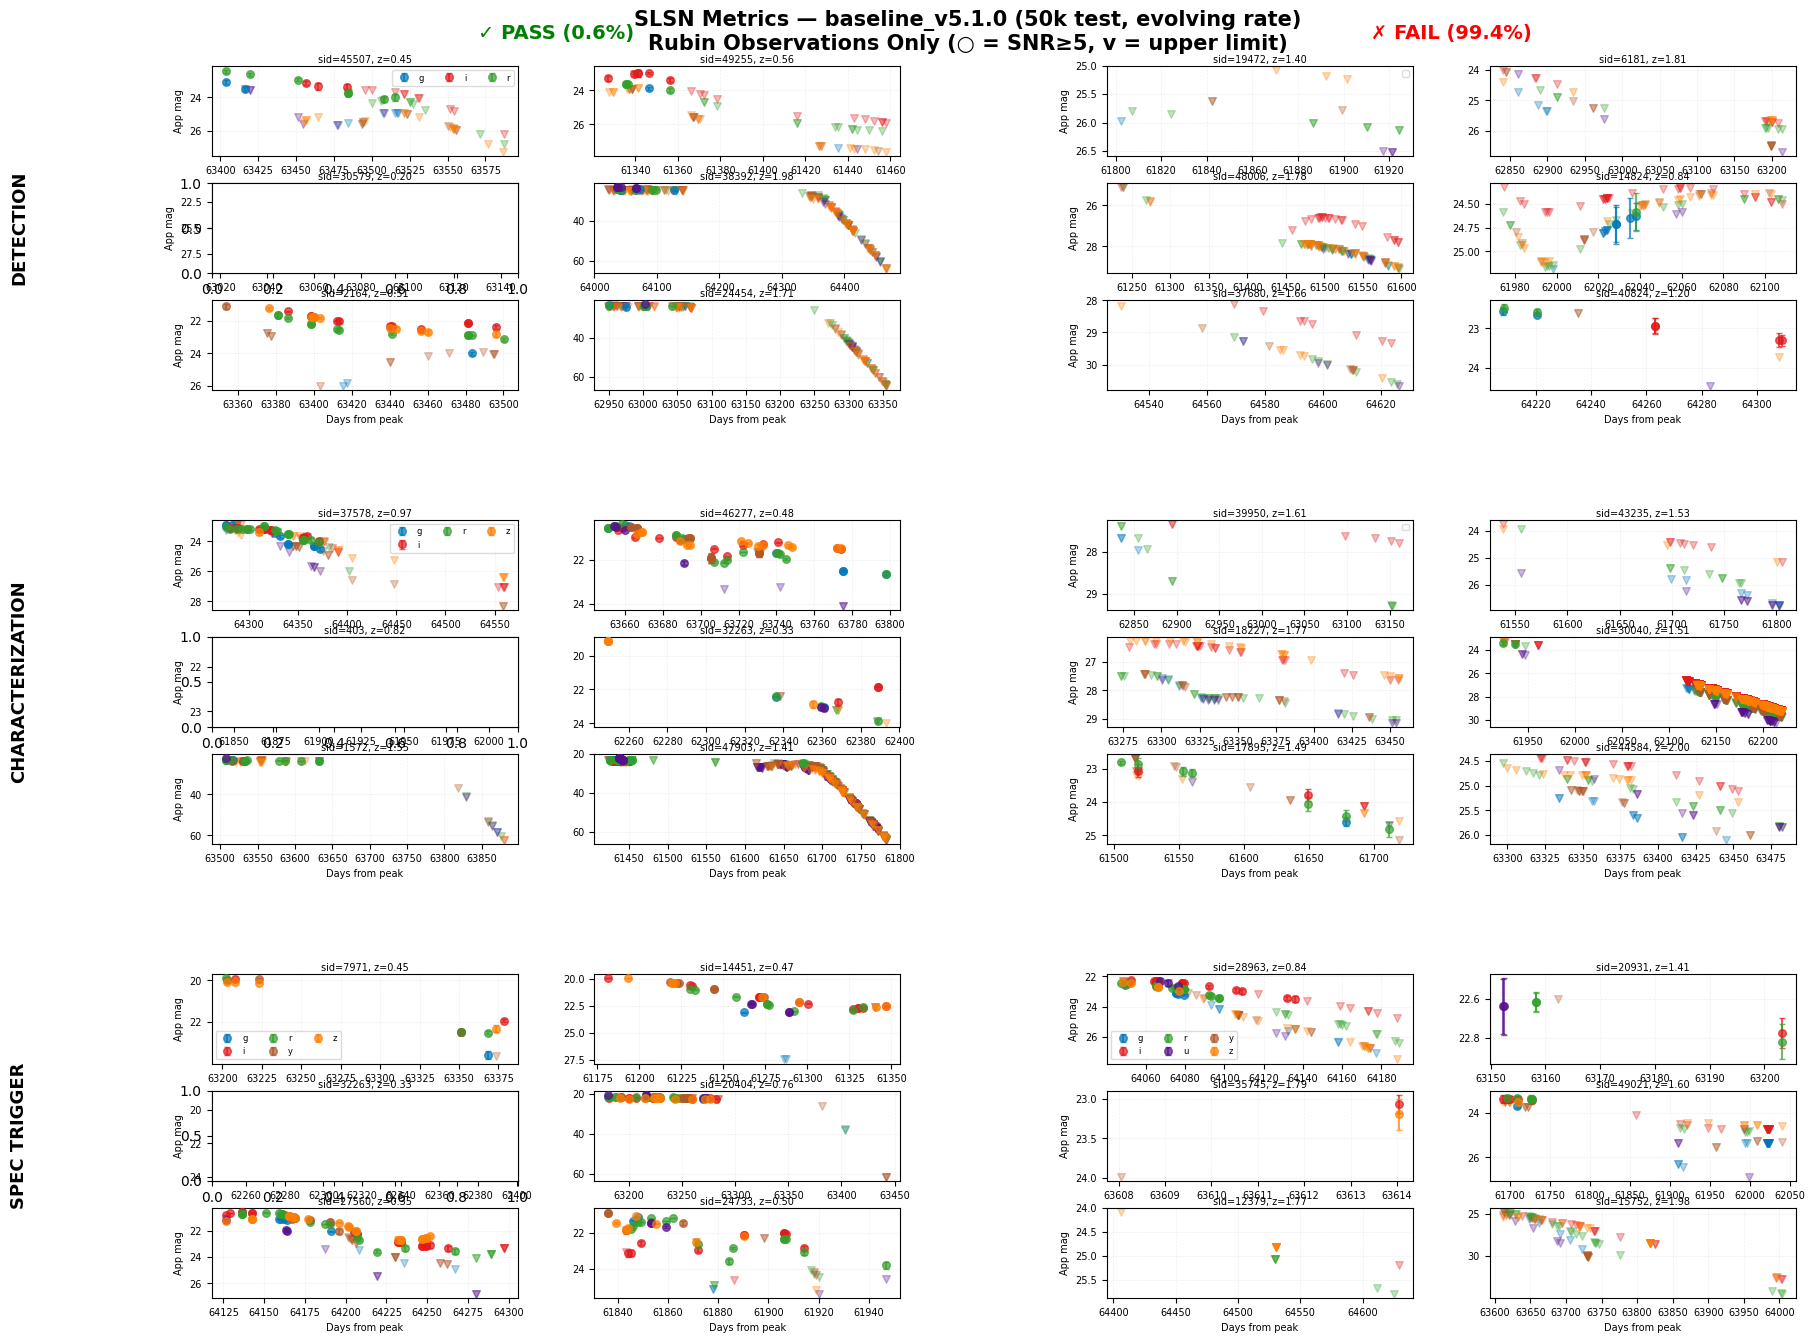

In [14]:
# ============================================================================
# CELL 8: Mosaic diagnostic plots
# ============================================================================
from slsn_metrics.diagnostics import plot_metrics_mosaic_grid

from importlib import reload
import slsn_metrics.diagnostics as diag_mod
reload(diag_mod)
from slsn_metrics.diagnostics import plot_metrics_mosaic_grid

# Extract obs records from each metric
df_detect = pd.DataFrame.from_dict(
    metrics_list[0].obs_records, orient='index'
).reset_index(drop=True)

df_char = pd.DataFrame.from_dict(
    metrics_list[1].obs_records, orient='index'
).reset_index(drop=True)

df_spec = pd.DataFrame.from_dict(
    metrics_list[2].obs_records, orient='index'
).reset_index(drop=True)

print(f"detect : {len(df_detect)} events, {df_detect['detected'].sum()} detected")
print(f"char   : {len(df_char)} events, {df_char['characterized'].sum()} characterized")
print(f"spec   : {len(df_spec)} events, {df_spec['spec_trigger'].sum()} spec triggered")

fig = plot_metrics_mosaic_grid(
    df_detect,
    df_char,
    df_spec,
    n_examples  = 6,
    outpath     = Path(storage_dir) / "mosaic_baseline_v5.1.0_test.png",
    title_prefix = f"SLSN Metrics — baseline_v5.1.0 (50k test, evolving rate)"
)

## Light Curve Inspector — Templates and Population Events

This cell provides four independently toggleable views of the light curve
data, from raw GP templates through to fully corrected apparent magnitudes
for individual population events.

Set any combination of the four toggles to `True`:

| Toggle | What it shows |
|---|---|
| `SHOW_TEMPLATE_ABSOLUTE` | Raw GP template in absolute mag vs rest-frame phase — no distance, no extinction. Shows the intrinsic shape of the SLSN as fit from catalog data. |
| `SHOW_TEMPLATE_GRID` | One template split into per-filter panels — useful for checking GP coverage and smoothness in individual bands. |
| `SHOW_POPULATION_APPARENT` | Full apparent-magnitude LCs for randomly selected population events, with DM + E(B-V) applied and the WFD single-visit depth shown as a dashed line. |
| `SHOW_POPULATION_GRID` | Compact mosaic of N population events — the population-level equivalent of the metric mosaic. |

### What Each View Tells You

**Template absolute (Mode 1)**
The shape the GP learned from real SLSN photometry. All bands should peak
near phase~0 and decline monotonically. Bands with sparse catalog coverage
(typically u and y) may show flat or noisy behavior — this is expected and
is why the band mapping uses B→g, V→r, R→i rather than synthesizing u/y
from scratch.

**Template grid (Mode 2)**
Isolates individual filter fits. Useful for spotting GP artifacts: if one
filter shows a sharp upturn at late phases or non-monotonic behavior, it
indicates sparse catalog coverage in that band for that particular event.
Does not affect the population — the mag grid interpolates safely over
these regions and returns NaN outside template support.

**Population apparent (Mode 3)**
The same physical template shifted to a random event's distance and
reddened by its Galactic E(B-V). The dashed horizontal line at r~24.7
is the approximate Rubin WFD single-visit 5σ depth. Events where all
filter curves sit below (fainter than) this line will not be detected —
this is why high-z efficiency is low. Events that cross above the line
in multiple filters are detectable candidates.

**Population grid (Mode 4)**
The population-level view. A diverse random sample shows the range of
apparent brightness, color, and duration across the injected population.
Events at high-z (small distance modulus applied to already-faint
templates) cluster near or below the WFD limit. Events at z<0.5 sit
well above it — these are the efficiently detected events that contribute
disproportionately to the detection sample.

### Key Config Options

- `TEMPLATE_INDICES` — list of integer indices into `templates.data`
- `FILTERS` — subset of ugrizy to show (default: g, r, i, z)
- `USE_LOG_TIME` — log x-axis recommended; linear shows more detail near peak
- `POP_SEED` — change to see a different random sample of events
- `N_POP_GRID` — must be divisible by 3 (3-column layout)

### No Reloads Needed
All four modes read directly from `templates` and `pop_run` already in memory.


[MODE 1] Absolute templates — indices [0, 1, 2]


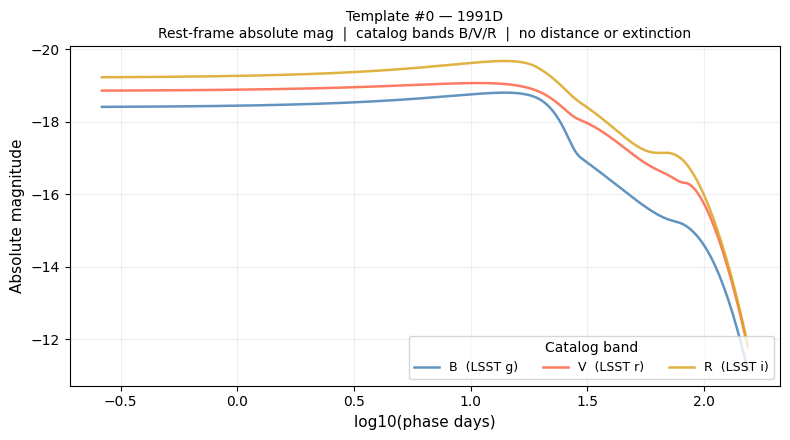

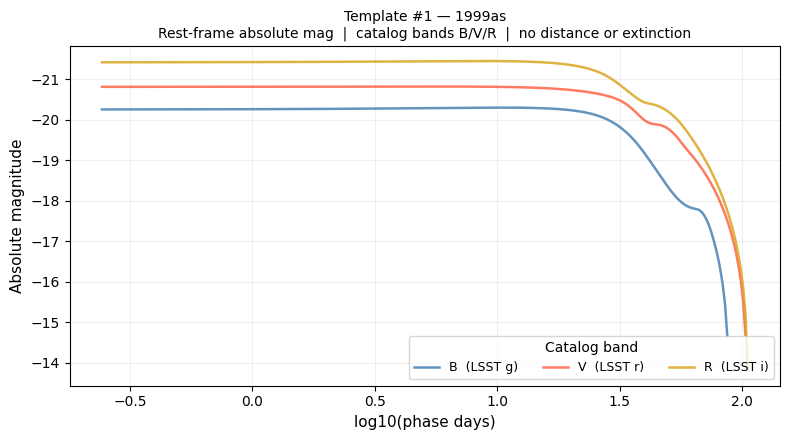

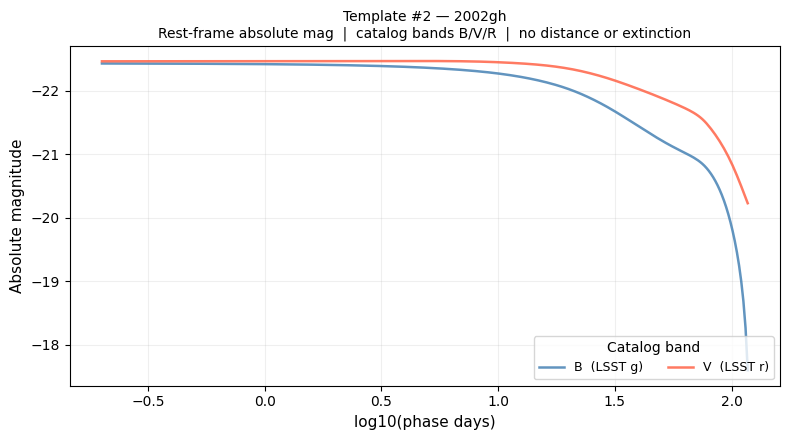


[MODE 2] Template grid — index 0 (1991D), bands ['B', 'V', 'R']


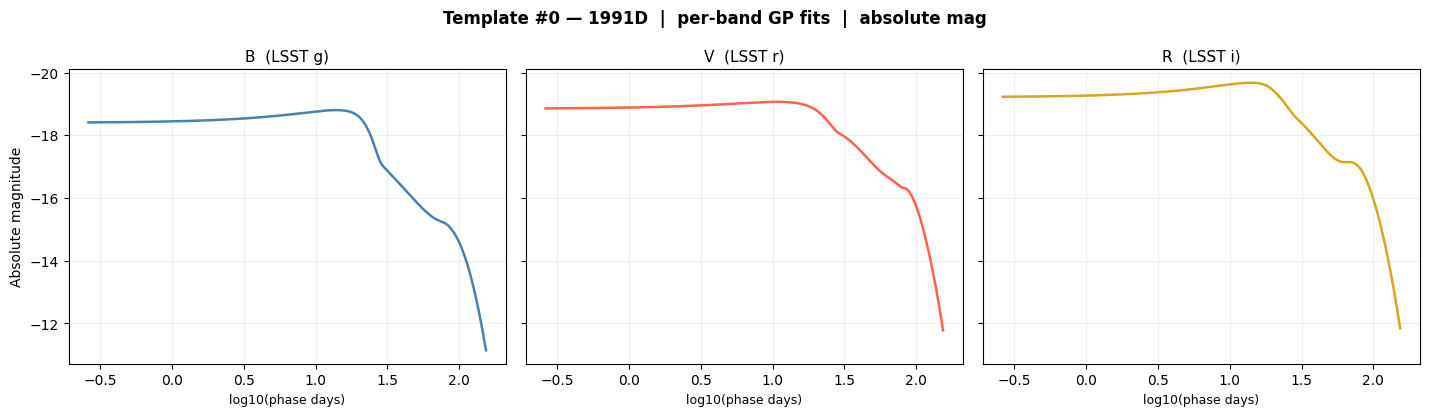


[MODE 3] Population apparent LCs — 4 events (seed=42)


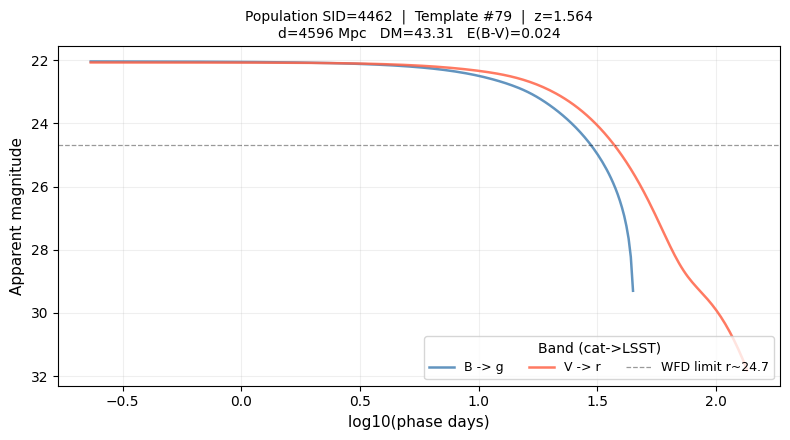


[MODE 4] Population grid — 12 events (4x3)


/tmp/ipykernel_568566/3022239242.py:298: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title='filter', ncol=1, fontsize=7, loc='lower right')


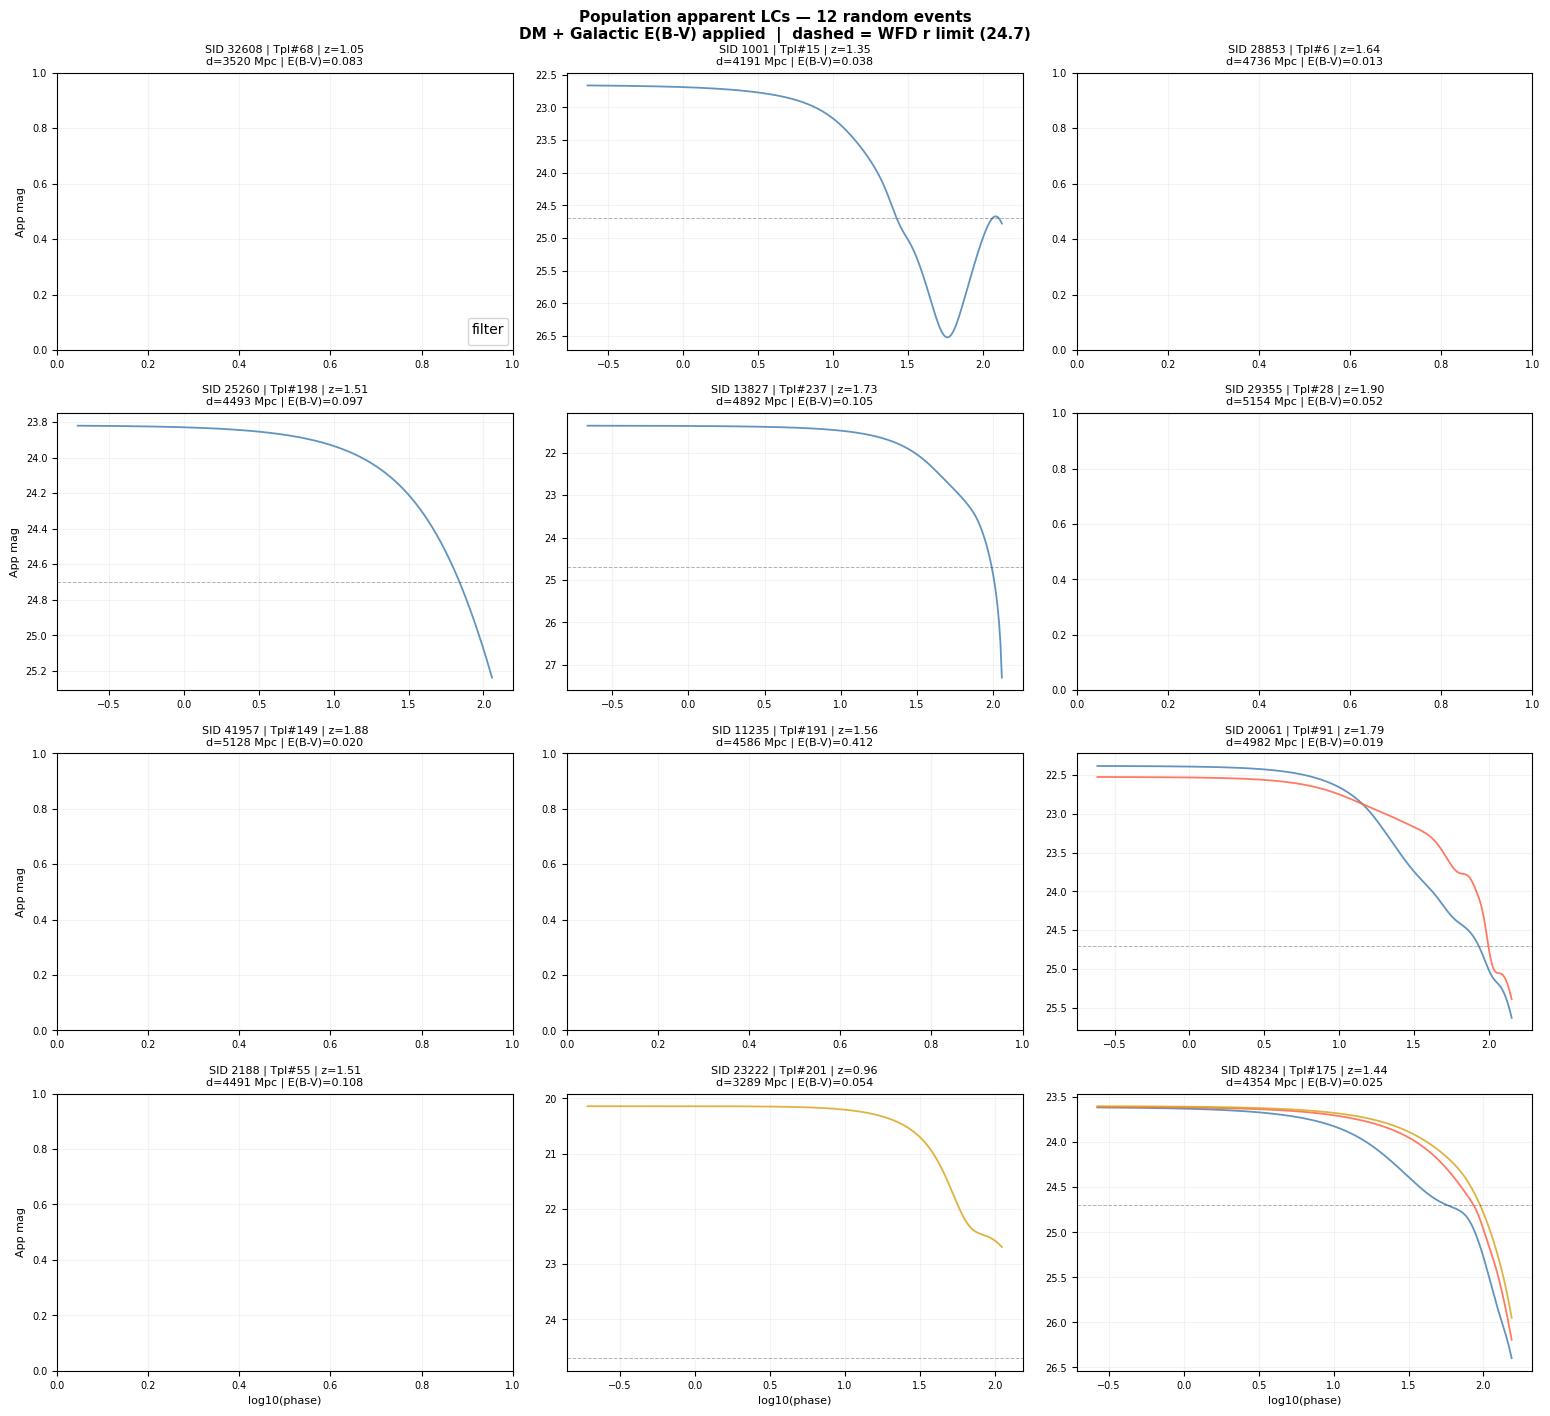


  LC inspection complete.


In [33]:
# ============================================================================
# CELL: Template & Population Light Curve Inspector
#
# Prerequisites: templates, pop_run already in memory
# No reloads needed.
#
# TOGGLE any combination of the four modes below.
# ============================================================================

import numpy as np
import matplotlib.pyplot as plt

# ── TOGGLES ──────────────────────────────────────────────────────────────────
SHOW_TEMPLATE_ABSOLUTE   = True   # Raw GP templates: absolute mag vs rest-frame phase
SHOW_TEMPLATE_GRID       = True   # All catalog bands side-by-side for one template
SHOW_POPULATION_APPARENT = True   # Apparent mag after DM + EBV for population events
SHOW_POPULATION_GRID     = True   # Compact grid of N random population events

# ── CONFIG ────────────────────────────────────────────────────────────────────
TEMPLATE_INDICES   = [0, 1, 2]    # which template indices (SHOW_TEMPLATE_ABSOLUTE)
TEMPLATE_GRID_IDX  = 0            # single template for SHOW_TEMPLATE_GRID
N_POP_EVENTS       = 4            # events for SHOW_POPULATION_APPARENT
N_POP_GRID         = 12           # events for SHOW_POPULATION_GRID (must be mult of 3)
POP_SEED           = 42           # random seed for event selection
USE_LOG_TIME       = True         # log x-axis (recommended)

# Templates store catalog bands B, V, R — mapped to nearest LSST band
CATALOG_BANDS = ['B', 'V', 'R']
BAND_MAP      = {'B': 'g', 'V': 'r', 'R': 'i'}   # catalog → LSST
LSST_LIMIT    = 24.7   # approximate WFD single-visit 5sigma r-band depth

CAT_COLORS  = {'B': 'steelblue', 'V': 'tomato', 'R': 'goldenrod'}
LSST_COLORS = {'g': 'steelblue', 'r': 'tomato', 'i': 'goldenrod',
               'u': 'violet', 'z': 'seagreen', 'y': 'dimgray'}

# ── DUST ─────────────────────────────────────────────────────────────────────
from rubin_sim.phot_utils import DustValues
dust_ax1 = DustValues().ax1   # LSST filter -> A_f / E(B-V)

# ── HELPERS ───────────────────────────────────────────────────────────────────
def _t_grid(tpl, use_log):
    """Return (t_plot, t_eval) spanning the union of all band phase supports."""
    all_ph = []
    for band in tpl:
        ph = np.asarray(tpl[band]['ph'], dtype=float)
        ph = ph[np.isfinite(ph) & (ph > 0)]
        if ph.size:
            all_ph.append(ph)
    if not all_ph:
        return np.array([]), np.array([])
    ph_all = np.concatenate(all_ph)
    t0, t1 = ph_all.min(), ph_all.max()
    t_eval = np.geomspace(max(t0, 0.1), t1, 300)
    t_plot = np.log10(t_eval) if use_log else t_eval
    return t_plot, t_eval

def _interp_band(tpl, band, t_eval):
    """Interpolate one catalog band onto t_eval; NaN outside support."""
    if band not in tpl:
        return np.full(len(t_eval), np.nan)
    ph  = np.asarray(tpl[band]['ph'],  dtype=float)
    mag = np.asarray(tpl[band]['mag'], dtype=float)
    ok  = np.isfinite(ph) & np.isfinite(mag) & (ph > 0)
    if ok.sum() < 2:
        return np.full(len(t_eval), np.nan)
    m = np.interp(t_eval, ph[ok], mag[ok], left=np.nan, right=np.nan)
    m[(t_eval < ph[ok].min()) | (t_eval > ph[ok].max())] = np.nan
    return m

def _apparent_mag(tpl, cat_band, lsst_band, t_eval, dm, ebv):
    """Absolute template + DM + Galactic extinction -> apparent mag."""
    m_abs = _interp_band(tpl, cat_band, t_eval)
    A_f   = dust_ax1.get(lsst_band, 0.0) * ebv
    return m_abs + dm + A_f

def _sp_val(key, sid):
    return float(np.asarray(pop_run.slice_points[key]).ravel()[sid])

# =============================================================================
# MODE 1: Raw absolute templates — one figure per index
# =============================================================================
if SHOW_TEMPLATE_ABSOLUTE:
    print(f"\n[MODE 1] Absolute templates — indices {TEMPLATE_INDICES}")
    for idx in TEMPLATE_INDICES:
        if idx >= len(templates.data):
            print(f"  index {idx} out of range ({len(templates.data)} templates)")
            continue

        tpl   = templates.data[idx]
        name  = templates.names[idx] if idx < len(templates.names) else f'#{idx}'
        avail = [b for b in CATALOG_BANDS if b in tpl]
        if not avail:
            print(f"  template {idx}: no B/V/R bands, has {list(tpl.keys())}")
            continue

        t_plot, t_eval = _t_grid(tpl, USE_LOG_TIME)
        if not t_eval.size:
            print(f"  template {idx}: empty phase grid"); continue

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for b in avail:
            m   = _interp_band(tpl, b, t_eval)
            fin = np.isfinite(m)
            if fin.sum() < 2:
                continue
            ax.plot(t_plot[fin], m[fin],
                    color=CAT_COLORS[b],
                    label=f'{b}  (LSST {BAND_MAP[b]})',
                    lw=1.8, alpha=0.85)

        ax.invert_yaxis()
        ax.set_xlabel('log10(phase days)' if USE_LOG_TIME else 'Phase (days)',
                      fontsize=11)
        ax.set_ylabel('Absolute magnitude', fontsize=11)
        ax.set_title(
            f'Template #{idx} — {name}\n'
            f'Rest-frame absolute mag  |  catalog bands B/V/R  |  no distance or extinction',
            fontsize=10)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(title='Catalog band', ncol=len(avail), fontsize=9,
                      loc='lower right')
        ax.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

# =============================================================================
# MODE 2: One template, each band in its own panel
# =============================================================================
if SHOW_TEMPLATE_GRID:
    idx = TEMPLATE_GRID_IDX
    if idx >= len(templates.data):
        print(f"  TEMPLATE_GRID_IDX={idx} out of range")
    else:
        tpl   = templates.data[idx]
        name  = templates.names[idx] if idx < len(templates.names) else f'#{idx}'
        avail = [b for b in CATALOG_BANDS if b in tpl]

        if not avail:
            print(f"  template {idx}: no B/V/R bands found, has {list(tpl.keys())}")
        else:
            t_plot, t_eval = _t_grid(tpl, USE_LOG_TIME)
            ncols = len(avail)
            print(f"\n[MODE 2] Template grid — index {idx} ({name}), bands {avail}")

            fig, axes = plt.subplots(1, ncols,
                                     figsize=(4.8 * ncols, 4.2),
                                     sharey=True, sharex=True)
            if ncols == 1:
                axes = [axes]

            for ai, b in enumerate(avail):
                ax  = axes[ai]
                m   = _interp_band(tpl, b, t_eval)
                fin = np.isfinite(m)
                if fin.sum() >= 2:
                    ax.plot(t_plot[fin], m[fin],
                            color=CAT_COLORS[b], lw=1.8)
                ax.invert_yaxis()
                ax.set_title(f'{b}  (LSST {BAND_MAP[b]})', fontsize=11)
                ax.set_xlabel(
                    'log10(phase days)' if USE_LOG_TIME else 'Phase (days)',
                    fontsize=9)
                if ai == 0:
                    ax.set_ylabel('Absolute magnitude', fontsize=10)
                ax.grid(True, alpha=0.2)

            fig.suptitle(
                f'Template #{idx} — {name}  |  per-band GP fits  |  absolute mag',
                fontsize=12, fontweight='bold')
            plt.tight_layout()
            plt.show()

# =============================================================================
# MODE 3: Population apparent-mag LCs — one figure per event
# =============================================================================
if SHOW_POPULATION_APPARENT:
    sp   = pop_run.slice_points
    n_sp = len(np.asarray(sp['file_indx']).ravel())
    rng  = np.random.default_rng(POP_SEED)
    sids = rng.choice(n_sp, size=min(N_POP_EVENTS, n_sp), replace=False)
    print(f"\n[MODE 3] Population apparent LCs — {len(sids)} events (seed={POP_SEED})")

    for sid in sids:
        idx      = int(_sp_val('file_indx', sid))
        dist_mpc = _sp_val('distance', sid)
        ebv      = _sp_val('ebv', sid)
        z_val    = _sp_val('z', sid)
        dm       = 5 * np.log10(dist_mpc * 1e6) - 5

        if idx >= len(templates.data):
            print(f"  SID {sid}: file_indx {idx} out of range"); continue

        tpl   = templates.data[idx]
        avail = [b for b in CATALOG_BANDS if b in tpl]
        if not avail:
            continue

        t_plot, t_eval = _t_grid(tpl, USE_LOG_TIME)
        if not t_eval.size:
            continue

        fig, ax = plt.subplots(figsize=(8, 4.5))
        for b in avail:
            lsst_b = BAND_MAP[b]
            m_app  = _apparent_mag(tpl, b, lsst_b, t_eval, dm, ebv)
            fin    = np.isfinite(m_app)
            if fin.sum() < 2:
                continue
            ax.plot(t_plot[fin], m_app[fin],
                    color=LSST_COLORS[lsst_b],
                    label=f'{b} -> {lsst_b}',
                    lw=1.8, alpha=0.85)

        ax.axhline(LSST_LIMIT, ls='--', lw=0.9, color='k', alpha=0.4,
                   label=f'WFD limit r~{LSST_LIMIT}')
        ax.invert_yaxis()
        ax.set_xlabel('log10(phase days)' if USE_LOG_TIME else 'Phase (days)',
                      fontsize=11)
        ax.set_ylabel('Apparent magnitude', fontsize=11)
        ax.set_title(
            f'Population SID={sid}  |  Template #{idx}  |  z={z_val:.3f}\n'
            f'd={dist_mpc:.0f} Mpc   DM={dm:.2f}   E(B-V)={ebv:.3f}',
            fontsize=10)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(title='Band (cat->LSST)', ncol=len(avail)+1,
                      fontsize=9, loc='lower right')
        ax.grid(True, alpha=0.2)
        plt.tight_layout()
        plt.show()

# =============================================================================
# MODE 4: Compact grid of N population events
# =============================================================================
if SHOW_POPULATION_GRID:
    sp   = pop_run.slice_points
    n_sp = len(np.asarray(sp['file_indx']).ravel())
    rng  = np.random.default_rng(POP_SEED + 1)
    sids = rng.choice(n_sp, size=min(N_POP_GRID, n_sp), replace=False)
    ncols = 3
    nrows = int(np.ceil(len(sids) / ncols))
    print(f"\n[MODE 4] Population grid — {len(sids)} events ({nrows}x{ncols})")

    fig, axes = plt.subplots(nrows, ncols,
                             figsize=(5.2 * ncols, 3.6 * nrows))
    axes = np.array(axes).flatten()

    for ai, sid in enumerate(sids):
        ax       = axes[ai]
        idx      = int(_sp_val('file_indx', sid))
        dist_mpc = _sp_val('distance', sid)
        ebv      = _sp_val('ebv', sid)
        z_val    = _sp_val('z', sid)
        dm       = 5 * np.log10(dist_mpc * 1e6) - 5

        if idx >= len(templates.data):
            ax.text(0.5, 0.5, f'idx {idx} OOB',
                    ha='center', va='center', transform=ax.transAxes)
            ax.axis('off')
            continue

        tpl   = templates.data[idx]
        avail = [b for b in CATALOG_BANDS if b in tpl]
        t_plot, t_eval = _t_grid(tpl, USE_LOG_TIME)

        plotted = False
        for b in avail:
            lsst_b = BAND_MAP[b]
            m_app  = _apparent_mag(tpl, b, lsst_b, t_eval, dm, ebv)
            fin    = np.isfinite(m_app)
            if fin.sum() < 2:
                continue
            ax.plot(t_plot[fin], m_app[fin],
                    color=LSST_COLORS[lsst_b],
                    label=f'{b}->{lsst_b}',
                    lw=1.3, alpha=0.85)
            plotted = True

        if plotted:
            ax.axhline(LSST_LIMIT, ls='--', lw=0.7, color='k', alpha=0.3)
            ax.invert_yaxis()

        ax.set_title(
            f'SID {sid} | Tpl#{idx} | z={z_val:.2f}\n'
            f'd={dist_mpc:.0f} Mpc | E(B-V)={ebv:.3f}',
            fontsize=8)
        ax.grid(True, alpha=0.15)
        ax.tick_params(labelsize=7)

        if ai % ncols == 0:
            ax.set_ylabel('App mag', fontsize=8)
        if ai >= (nrows - 1) * ncols:
            ax.set_xlabel(
                'log10(phase)' if USE_LOG_TIME else 'Phase (d)',
                fontsize=8)
        if ai == 0:
            ax.legend(title='filter', ncol=1, fontsize=7, loc='lower right')

    for ai in range(len(sids), len(axes)):
        axes[ai].set_visible(False)

    fig.suptitle(
        f'Population apparent LCs — {len(sids)} random events\n'
        f'DM + Galactic E(B-V) applied  |  dashed = WFD r limit ({LSST_LIMIT})',
        fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("\n  LC inspection complete.")

## Interpreting These Results: Test Run Context and Science Implications

> **Important context**: These results come from a 50,000-event test subsample
> evaluated against a single cadence (`baseline_v5.1.0`). Efficiencies are
> statistically valid — they are unbiased estimates of the full-population
> result — but the absolute yield numbers are extrapolations. The full
> ~4.7M event batch job will confirm these fractions with higher precision.
> Cadence comparisons require running additional OpSim databases, which is
> the next step after this validation run.

---

### What the Failure Mode Breakdown Tells Us

The failure mode breakdown is the most diagnostic output of this analysis
because it identifies *which property of the cadence* is the limiting factor
for SLSN detection — and therefore which cadence modifications would most
improve science return.

**71% fail `failed_multiband_SNR` — depth is the dominant limitation.**
These events received Rubin observations but never reached SNR≥5 in two
filters simultaneously. They are simply too faint — predominantly the z>1
population sitting at r~24.5–26, near or below Rubin's single-visit limit
of r ~ 24.7 (5σ, 30s WFD). This bottleneck cannot be fixed by visiting more
frequently; it requires either deeper co-added visits, a redder filter
strategy (SLSNe are brighter in i/z at high-z due to redshifting of the
UV peak), or restricting science claims to z<1 where depth is sufficient.

**29% fail `failed_rising_LC` — cadence frequency is the secondary bottleneck.**
These events are bright enough to detect but Rubin's inter-night gaps
(typically 3–5 days in WFD) miss the rising phase window. SLSNe rise over
20–50 days rest-frame; at z~0.5–1.0 the observed rise is 30–75 days, so
Rubin should catch this in principle. The failures here represent unlucky
timing — events that peaked between survey visits or in seasonal gaps.
This fraction would improve most with a rolling cadence strategy or
increased visit frequency in the WFD footprint.

**<0.1% fail `failed_baseline_15d` — temporal baseline is never the bottleneck.**
Only 7 events fail here. Once an event is bright enough and a rising phase
is confirmed, Rubin's cadence naturally spans ≥15 days. This criterion
can be considered effectively free under the baseline strategy.

**0% have no sky coverage.**
Every injected event received at least one Rubin observation, confirming
the HEALPix population correctly covers the survey footprint. The 34,341
events with observations out of 34,341 total (68.7% of the 50,000 injected)
reflects the effective WFD footprint fraction for isotropically distributed
sources (~18,000 deg² / 41,253 deg² full sky ≈ 43.6% geometric, larger
in practice because repeat visits extend the effective detection area).

---

### Headline Science Numbers (Preliminary)

These are extrapolated from the 50,000-event test run to the full
~4.7M population. Statistical precision is ~1/√216 ≈ 7% on the
detection efficiency — sufficient for a presentation, not for publication.

| Result | Value | Context |
|---|---|---|
| Detections (10 yr) | ~30,000 | ~3,000 per year |
| Characterized (10 yr) | ~9,000 | ~900 per year; science-grade light curves |
| Spec triggers (10 yr) | ~960 | ~96 per year; mag≤21, 4–8m accessible |
| Improvement over pre-LSST | ~170× per year | 261 known SLSNe took ~15 yr to accumulate |
| Time to match all known SLSNe | ~32 days | At the detection rate above |

---

### What the Conditional Efficiencies Tell Us

**Only 31% of detected SLSNe get characterized.**
The cadence detects far more than it can characterize. The bottleneck shifts
from *depth* (for detection) to *sampling density* (for characterization).
The `SLSN_CharacterizeMetric` requires ≥2 epochs within ±10 days of peak
and ≥1 epoch beyond +30 days post-peak — criteria the baseline WFD cadence
often fails to satisfy because its revisit timescale (~3–5 days) is
irregular and does not guarantee peak coverage.

This 31% figure is the strongest quantitative argument for a rolling cadence
or mini-survey component: improving it to ~60% would roughly double the
characterized sample without requiring any new telescope time — just
redistributing existing visits.

**Only 11% of characterized events trigger spectroscopy.**
The mag≤21 brightness cut at ±5 days of peak is genuinely restrictive —
this is a real physical limit of current 4–8m spectrographs, not an
artifact of the metric. The ~96/yr spectroscopic trigger rate is the
number to bring to follow-up facility discussions (4MOST, DESI, VLT/FORS2,
Keck/LRIS). These are the highest-value SLSN targets for the LSST era:
bright, near-peak, blue, and photometrically well-characterized.

---

### What to Run Next

1. **Full ~4.7M population batch job on MSI** — confirms efficiency fractions
   with <1% statistical uncertainty; provides publication-quality yield numbers
2. **Cadence comparison** — run 3–5 additional OpSim databases
   (rolling cadence variants, presto-color, DDF fields) to quantify how much
   the `failed_rising_LC` fraction improves with increased visit frequency
3. **Sensitivity analysis** — vary OH_max (8.3, 8.7, 9.0, 9.3) and the
   Andrews & Martini slope (−0.14, −0.30, −0.45) to bracket rate model
   uncertainty on the absolute yield numbers

-------------------------------------------

# Check the dataframe diagnostic

In [15]:
# ============================================
# DIAGNOSTIC: Check what's in the dataframes
# ============================================
import pandas as pd

print("\n" + "="*70)
print("DATAFRAME DIAGNOSTICS")
print("="*70)

# Check DETECTION dataframe
print("\n1. DETECTION DataFrame:")
print(f"   Columns: {df_detect.columns.tolist()}")
print(f"   Has 'detected': {'detected' in df_detect.columns}")
if 'detected' in df_detect.columns:
    print(f"   True count: {df_detect['detected'].sum()}")
    print(f"   False count: {(~df_detect['detected']).sum()}")
    print(f"   Detection rate: {df_detect['detected'].mean():.1%}")

# Check CHARACTERIZATION dataframe
print("\n2. CHARACTERIZATION DataFrame:")
print(f"   Columns: {df_char.columns.tolist()}")
print(f"   Has 'characterized': {'characterized' in df_char.columns}")
if 'characterized' in df_char.columns:
    print(f"   True count: {df_char['characterized'].sum()}")
    print(f"   False count: {(~df_char['characterized']).sum()}")
    print(f"   Characterization rate: {df_char['characterized'].mean():.1%}")
else:
    print("   ⚠️  'characterized' column MISSING!")

# Check SPEC TRIGGER dataframe
print("\n3. SPEC TRIGGER DataFrame:")
print(f"   Columns: {df_spec.columns.tolist()}")
print(f"   Has 'spec_trigger': {'spec_trigger' in df_spec.columns}")
if 'spec_trigger' in df_spec.columns:
    print(f"   True count: {df_spec['spec_trigger'].sum()}")
    print(f"   False count: {(~df_spec['spec_trigger']).sum()}")
    print(f"   Spec trigger rate: {df_spec['spec_trigger'].mean():.1%}")
else:
    print("   ⚠️  'spec_trigger' column MISSING!")

# Check observation data
print("\n4. OBSERVATION DATA CHECK:")
required_obs_cols = ['mjd_obs', 'mag_obs', 'filter', 'snr_obs']
for col in required_obs_cols:
    print(f"   {col:15s}: detect={col in df_detect.columns}, "
          f"char={col in df_char.columns}, spec={col in df_spec.columns}")

print("="*70 + "\n")


DATAFRAME DIAGNOSTICS

1. DETECTION DataFrame:
   Columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'detected', 'sid', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'peak_time']
   Has 'detected': True
   True count: 216
   False count: 34125
   Detection rate: 0.6%

2. CHARACTERIZATION DataFrame:
   Columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'characterized', 'n_epochs', 'n_filters_char', 'sid', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'peak_time']
   Has 'characterized': True
   True count: 66
   False count: 34275
   Characterization rate: 0.2%

3. SPEC TRIGGER DataFrame:
   Columns: ['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'spec_trigger', 'min_mag_near_peak', 'has_g_near_peak', 'has_r_near_peak', 'sid', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'peak_time']
   Has 'spec_trigger': True
   True count: 7
   False count: 34334
   Spec trigger rate: 0.0%

4. OBSERVATION DATA CHECK:
   mjd_obs        : detect

In [17]:
print(df_detect.columns.tolist())
print(df_detect.dtypes)
print(df_detect.head(2))

['mjd_obs', 'mag_obs', 'snr_obs', 'filter', 'available_bands', 'detected', 'sid', 'file_indx', 'z', 'ra', 'dec', 'distance_Mpc', 'ebv', 'peak_time']
mjd_obs             object
mag_obs             object
snr_obs             object
filter              object
available_bands        str
detected              bool
sid                  int64
file_indx            int64
z                  float64
ra                 float64
dec                float64
distance_Mpc       float64
ebv                float64
peak_time          float64
dtype: object
                                             mjd_obs  \
0  [61464.33387554309, 61464.310137066, 61464.355...   
1  [62316.101667621566, 62317.96014780267, 62316....   

                                             mag_obs  \
0  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...   
1  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...   

                                             snr_obs  \
0  [nan, nan, nan, nan, nan, nan, nan, nan, nan, ...   
1  [nan, 

In [18]:
# Check template durations for detected events
sp = pop_run.slice_points
sid_arr = np.asarray(sp['sid'])

# For detected events, get their template index and duration
det_rows = df_detect[df_detect['detected'] == True]
print("Detected event template durations:")
for _, row in det_rows.head(10).iterrows():
    idx = int(row['file_indx'])
    ph = np.asarray(templates.data[idx]['r']['ph'], float)
    duration = ph.max() - ph.min()
    inj_mag = sp['peak_app_mag_ebv_r'][sid_arr == row['sid']][0]
    print(f"  sid={row['sid']:5d}  file_indx={idx:3d}  duration={duration:6.1f}d  inj_r={inj_mag:.2f}  obs_r={row.get('per_filter_min_mag', {}).get('r', float('nan')):.2f}")

Detected event template durations:
  sid=  383  file_indx= 38  duration= 155.6d  inj_r=24.08  obs_r=nan
  sid=  403  file_indx= 89  duration= 117.8d  inj_r=21.46  obs_r=nan
  sid=  434  file_indx= 32  duration= 146.9d  inj_r=22.12  obs_r=nan
  sid=  458  file_indx=203  duration= 151.6d  inj_r=23.00  obs_r=nan
  sid=  853  file_indx=203  duration= 151.6d  inj_r=22.18  obs_r=nan
  sid=  917  file_indx= 51  duration= 150.5d  inj_r=22.41  obs_r=nan
  sid= 1071  file_indx= 32  duration= 146.9d  inj_r=23.45  obs_r=nan
  sid= 1202  file_indx= 41  duration= 148.8d  inj_r=23.55  obs_r=nan
  sid= 1241  file_indx=116  duration= 127.9d  inj_r=21.52  obs_r=nan
  sid= 1249  file_indx= 97  duration= 136.9d  inj_r=23.13  obs_r=nan
